# Boat detection  with Sentinel 1

In this notebook, we pre-process Sentinel 1 data for use in a boat detection model. We used known location of boat/dredge to define a small window and download and process data in a seven date window.

We use rioxarray to create an xarray object to visualize the boat locations. Cropped window will be use to define bounding boxes used in a Deep Learning object detection model.

# Data

We use data products from the Sentinel 1 Mission from the Copernicus programme. Sentinel 1 consists of two satellite platforms collecting imagery with the same Synthetic Aperture Radar (SAR) sensor using C-band. It collects imagery day and night independent of weather.

The first satellite Sentinel 1A was launched on April 3, 2014 while Sentinel 1B was launched on April 23 2016. The satellites have revisit time of 12 days and 6 days when combined together. Sentinel 1 comes in different types of products:
- SLC and GRD products are not georeferenced/projected on the earth and need to undergo several processing steps to correct data acquisition and geometric distortions.
- RTC product is an analysis ready data that uses the UTM gridding system.

Because the satellite path crosses the meridians the tiles collected are triangular or trapezoidal in shape and do not follow the UTM square gridding that is usually used to reproject the data.

# Using STAC to explore and download COGS data

STAC or Spatial Temporal Assets Catalog along with COG (Cloud Optimized Geotiff) are quickly becoming a standard in distributing Earth Observation data. We use STAC to search, access and download the data for the dates matching the boat occurences and locations.

## Interesting links:

- GDAL tutorial:

https://www.kaggle.com/code/samanemami/a-complete-tutorial-on-raster-data-analysis?scriptVersionId=110771922


- planetary computer:

https://colab.research.google.com/github/radiantearth/stac-site/blob/main/notebooks/src/planetary-computer-reading-stac.ipynb

- Sentinel 1 access and products

https://planetarycomputer.microsoft.com/dataset/group/sentinel-1

https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-1/overviews


- Copernicus Dataspace Ecosystem

https://documentation.dataspace.copernicus.eu/APIs/STAC.html


- Visualize and explore multibands time series from Sentinel with xarray


https://medium.com/@bonnefond.virginie/handling-multi-temporal-satellite-images-with-xarray-30d142d3391

- NASA Earth data via STAC

https://nasa-openscapes.github.io/2021-Cloud-Hackathon/tutorials/02_Data_Discovery_CMR-STAC_API.html

https://hls.gsfc.nasa.gov/products-description/tiling-system/




# Set up environment and load libraries

- load libraries
- install packages and tools
- authenticate to google drive and gcp account

First let's install GDAL binaries.

In [ ]:
#install gdal to run from the terminal
!sudo add-apt-repository ppa:ubuntugis/ppa -y
!sudo apt-get update
!sudo apt-get install gdal-bin
!gdalinfo --version

PPA publishes dbgsym, you may need to include 'main/debug' component
Repository: 'deb https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/ jammy main'
Description:
Official stable UbuntuGIS packages.


More info: https://launchpad.net/~ubuntugis/+archive/ubuntu/ppa
Adding repository.
Found existing deb entry in /etc/apt/sources.list.d/ubuntugis-ubuntu-ppa-jammy.list
Adding deb entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ppa-jammy.list
Found existing deb-src entry in /etc/apt/sources.list.d/ubuntugis-ubuntu-ppa-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/ubuntugis-ubuntu-ppa-jammy.list
Adding key to /etc/apt/trusted.gpg.d/ubuntugis-ubuntu-ppa.gpg with fingerprint 2EC86B48E6A9F326623CD22FFF0E7BBEC491C6A1
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Hit:3 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:4 http://security.ubuntu.com/ubuntu jammy-secur

Install other geospatial related libraries

In [ ]:
!pip install fiona

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.6/56.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 94.1 MB/s eta 0:00:00


In [ ]:
#set up libararies for GIS/Geospatial
try: # try the following b+lock of code
  import geopandas as gpd
except: # if the try block throws an error, run the following
  !pip install geopandas # install geopandas
  import geopandas as gpd

try:
  import contextily as ctx # import
  import rasterio
except:
  !apt install libproj-dev proj-data proj-bin
  !apt install libgeos-dev
  !pip install cython
  !pip install cartopy
  !pip install rasterio
import fiona # library for reading/writing GIS files, comes w/ geopandas
from shapely.geometry import Point, LineString, Polygon

!pip install pyproj
# Mapping,vector related imports
import geopandas as gpd
#import descartes #nessary for plotting in geopandas
from cartopy import crs as ccrs
from pyproj import Proj
#from osgeo import osr
from shapely import geometry
from shapely.geometry import Point
from shapely.geometry import box
from shapely.geometry import shape
from shapely.geometry import Polygon

from collections import OrderedDict
#rasterio imports, gdal and imagery utility
import rasterio
from rasterio.windows import Window
from osgeo import gdal
from rasterio import plot
from PIL import Image

#xarray and rio
!pip install rioxarray
!pip install mapclassify
!pip install earthpy

import mapclassify
import folium
import pyproj as proj
import xarray as xr
import rioxarray as rxr
import earthpy as et
import earthpy.plot as ep
from folium.utilities import none_max
import folium
from pyproj import Transformer

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libproj-dev is already the newest version (9.3.1-1~jammy0).
libproj-dev set to manually installed.
proj-data is already the newest version (9.3.1-1~jammy0).
proj-data set to manually installed.
The following NEW packages will be installed:
  proj-bin
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 205 kB of archives.
After this operation, 521 kB of additional disk space will be used.
Get:1 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy/main amd64 proj-bin amd64 9.3.1-1~jammy0 [205 kB]
Fetched 205 kB in 1s (228 kB/s)
Selecting previously unselected package proj-bin.
(Reading database ... 127765 files and directories currently installed.)
Preparing to unpack .../proj-bin_9.3.1-1~jammy0_amd64.deb ...
Unpacking proj-bin (9.3.1-1~jammy0) ...
Setting up proj-bin (9.3.1-1~jammy0) ...
Processing triggers for man-db (2.10.2-1) ...
Reading package lists... Don

General purpose libraries and packages

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as colors
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib import colors
import matplotlib.patches as mpatches
import seaborn as sns

import numpy as np
import subprocess
import pandas as pd
import os, glob
import zipfile

from pathlib import Path

sns.set_style('darkgrid')
#pd.set_option('display.max_colwidth', None)
!apt install unzip
import urllib
import re
import math
from datetime import datetime
from copy import deepcopy
from numpy.core.multiarray import datetime_as_string
import os
import numpy.ma as ma

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
unzip is already the newest version (6.0-26ubuntu3.2).
0 upgraded, 0 newly installed, 0 to remove and 41 not upgraded.


/tmp/ipython-input-975698043.py:25: DeprecationWarning: numpy.core.multiarray is deprecated and has been renamed to numpy._core.multiarray. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.multiarray.datetime_as_string.
  from numpy.core.multiarray import datetime_as_string


In [ ]:
#Used in defining functions
from typing import List, Tuple, Dict, Any
from pandas.core.arrays import boolean

In [ ]:
import cartopy.crs
import cartopy.feature as cfeature
#import dask.distributed
import ee
import google.auth.compute_engine
import matplotlib.pyplot as plt
import xarray as xr

In [ ]:
!sudo apt install tree

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  tree
0 upgraded, 1 newly installed, 0 to remove and 41 not upgraded.
Need to get 47.9 kB of archives.
After this operation, 116 kB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tree amd64 2.0.2-1 [47.9 kB]
Fetched 47.9 kB in 0s (379 kB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dialog.pm line 78, <> line 1.)
debconf: falling back to frontend: Readline
debconf: unable to initialize frontend: Readline
debconf: (This frontend requires a controlling tty.)
debconf: falling back to frontend: Teletype
dpkg-preconfigure: unable to re-open stdin: 
Selecting previously unselected package tree.
(Reading database ... 127791 files and directories currently install

Install STAC related libraries

- https://pystac-client.readthedocs.io/_/downloads/en/stable/pdf/
- https://github.com/stac-utils/pystac-client/blob/df034494c2d566f0b2fa6fb8f0455f75d10e0b62/docs/tutorials/aoi-coverage.ipynb


In [ ]:
!pip install pystac
#!pystac_client
!pip install pystac-client
!pip install planetary-computer
import planetary_computer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.7/207.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 1.4 MB/s eta 0:00:00


In [ ]:
#GCP account authentification
from google.colab import auth
auth.authenticate_user()
print('Authenticated')

Authenticated


In [ ]:
from google.colab import drive

drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [ ]:
#!nvidia-smi -L

Setting up environmental variables. We are using dotenv python package to set the environmental variables.


In [ ]:
!pip install tree

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 2.7 MB/s eta 0:00:00
  Created wheel for tree: filename=Tree-0.2.4-py3-none-any.whl size=7860 sha256=d1c1ee81988c543c530f442495bdd514d4e48ec8a8495027b9205bbea8fc8d53
  Stored in directory: /root/.cache/pip/wheels/30/5d/07/26dd4c076f0f5d0ad32b46fedc90eef891b258b1da16033846
Successfully built tree


In [ ]:
!pip install python-dotenv

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving .env to .env


Let's upload .env

In [ ]:
import dotenv
dotenv.load_dotenv('./.env')

True

# Functions
In the next part of the script, we declare all the functions used in the sripts.  It is good practice to place functions at the beginning of a script or in an external source file. Here are the 13 functions used:

In [ ]:
def create_dir_and_check_existence(path: str) -> str:
  '''
  Create a new directory

  :param path: path to the directory
  :return: path to the directory
  '''

  try:
    os.makedirs(path)
  except:
    print ("directory already exists")
  return path



In [ ]:
def dms_to_dd(val: np.float32) -> np.float32:
  '''
  Convert dms: degree minute second to decimal degree
  Note that the format expect direction with W or S.

  :param val: degree minute second
  :return: decimal degree
  '''

  deg,minute,second,direction = re.split('[°\'\"]', val)
  dd_val = float(deg)+float(minute)/60+float(second)/(60*60)
  if direction == 'W' or direction == 'S':
    dd_val = (-1.)*dd_val
  return dd_val

In [ ]:

def bbox_to_poly(bbox: list) -> Polygon:

  '''
  Convert bounding box list into a polygon. With input list xmin,ymin,xmax,ymax.

  :param bbox list: list of coordinates represending a bouding.
  :return: Shapely polygon

  '''

  long0 = bbox[0]
  lat0 = bbox[1]
  long1=bbox[2]
  lat1=bbox[3]

  poly = Polygon([[long0, lat0],
                        [long1,lat0],
                        [long1,lat1],
                        [long0, lat1]])

  return poly

In [ ]:
#remove +init epsg because depecated (October 2024)
def polygon_from_centroid(x_centroid,y_centroid,size,EPSG_val=4326)-> gpd.GeoDataFrame:

  '''

  Generate a square polygon from center point with a given size and EPSG code
  Return a GeoDataFrame

  :param x_centroid float32: x center of square polygon being created
  :param y_centroid float32: y center of square polygon being created
  :param size float32: length of square polygon
  :param EPSG_val int: EPSG code defining the coordinate system
  :return geopandas geodataframe

  '''

  xmin = x_centroid - size/2
  xmax = x_centroid + size/2
  ymin = y_centroid - size/2
  ymax = y_centroid + size/2

  bbox_list = [xmin,ymin,xmax,ymax]
  bbox_poly = bbox_to_poly(bbox_list)

  bbox_poly_gdf = gpd.GeoDataFrame(pd.DataFrame(['p1'], columns = ['geom']),
         crs = f'EPSG:{EPSG_val}',
         geometry = [bbox_poly])
  bbox_poly_gdf.to_file('bbox_poly.shp')

  return bbox_poly_gdf

In [ ]:
#https://aws.amazon.com/blogs/apn/transforming-geospatial-data-to-cloud-native-frameworks-with-element-84-on-aws/
#https://github.com/stac-utils/pystac-client/blob/1eaf0d97632c411279e8312b337faf842d657474/docs/tutorials/stac-metadata-viz.ipynb
def items_to_geodataframe(items: any) -> gpd.GeoDataFrame:
    '''
    Convert a list of STAC Items into a GeoDataFrame.
    Modified from https://github.com/stac-utils/pystac-client/blob/1eaf0d97632c411279e8312b337faf842d657474/docs/tutorials/stac-metadata-viz.ipynb

    :param items: list of STAC Items
    :return: GeoDataFrame
    '''

    #Using from copy import deepcopy
    _items = []
    for i in items:
        _i = deepcopy(i)
        _i['geometry'] = shape(_i['geometry'])
        _items.append(_i)
    gdf = gpd.GeoDataFrame(pd.json_normalize(_items))
    for field in ['properties.datetime', 'properties.created', 'properties.updated']:
        if field in gdf:
            gdf[field] = pd.to_datetime(gdf[field])
    gdf.set_index('properties.datetime', inplace=True)
    return gdf

In [ ]:
from pystac_client import item_search
#https://github.com/stac-utils/pystac-client/blob/1eaf0d97632c411279e8312b337faf842d657474/docs/tutorials/stac-metadata-viz.ipynb
#updated in September 2024
#updated in February 2025
def get_selected_products_and_bands(cat_search: item_search.ItemSearch,
                                    bands_selected: list[str],
                                    platform: str='Sentinel-2A') ->  Tuple[pd.DataFrame, gpd.GeoDataFrame]:

  '''
  Get the selected products and bands from STAC

  :param items: pystac_client item search object
  :param bands_selected: list of bands to filter
  :return: tuple with pandas data frame containing the selected products and bands and geodataframe containing footprint of data
  '''

  items_dict = [i.to_dict() for i in cat_search.items()]
  #print(f"{len(items_dict)} scenes fetched")
  items_gdf = items_to_geodataframe(items_dict)
  bands_selected_pattern = [f'assets.{b}.href'for b in bands_selected]
  if platform is 'Sentinel-2A':
    col_selected = bands_selected_pattern + ['collection','id','properties.s2:mgrs_tile','properties.proj:epsg']
  if platform in ['Sentinel-1A','Sentinel-1B']:
    col_selected = bands_selected_pattern + ['collection','id','properties.platform','properties.proj:epsg']
  else:
    col_selected = bands_selected_pattern + ['collection','id','properties.proj:code'] #change to code, need to check for sentinel 2

  if platform is not None:
    selected_products = items_gdf.loc[items_gdf['properties.platform']==platform,col_selected] #filter for relevant platform
  else:
    #col_selected = bands_selected
    selected_products = items_gdf.loc[:,col_selected] #filter for relevant platform

  selected_products = selected_products.reset_index()
  #print(selected_products['properties.datetime'].dtypes)
  selected_products['date'] = selected_products['properties.datetime'].dt.date
  selected_products['date'] = selected_products['date'].astype(str)

  return (selected_products,items_gdf)

<>:21: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:21: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipython-input-3565060019.py:21: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if platform is 'Sentinel-2A':


In [ ]:
#Change the name of the file to include date and better formatting
#Also adjust the resolution
#updated in September 2024
#updated in October 2024
#updated in February 2025
def download_and_reproject_stac_file(date_val:str,
                                     selected_products:pd.DataFrame,
                                     download: bool,
                                     aoi_poly:gpd.GeoDataFrame,
                                     out_prefix:str=None,
                                     output_epsg: int=None,
                                     output_res: np.float32=None,
                                     out_dir:str='.') -> str:
  '''
  Download and reproject STAC files

  :param date_val: str: date to download and process
  :param selected_products: pd.DataFrame
  :param download: boolean, if true download the raw file without processing
  :param aoi_poly: gpd.GeoDataFrame containing the reference poygon of Area of Interest
  :param out_prefix: str: prefix for output file name
  :param output_epsg: int code for EPSG projection coordinate system
  :param output_res: np.float32 resolution of output raster
  :param out_dir: str path to output directory
  :return: output raster file name containing the processed raster
   '''

  bands_cols = list(selected_products.filter(regex='assets').columns)
  out_raster_file = []

  for band in bands_cols:
    if download is True:
        raster_file_list = selected_products.loc[selected_products['date']==date_val,band].tolist()
        #out_raster_file =[]
        for raster_file in raster_file_list:
           download_path = os.path.join(selected_products.collection)
           in_filename = raster_file
           out_filename = os.path.basename(in_filename.split('?'))[0] #split the name on ?
           os.makedirs(download_path, exist_ok=True)
           out_filename = os.path.join(out_dir,out_filename)
           urllib.request.urlretrieve(in_filename,
                                   out_filename)

           out_raster_file.append(out_filename)

    #crop and project if download is false
    if download is False:
      #out_raster_file =[]
      # Set the AOI cropping
      #proj_crs = selected_products.loc[selected_products['date']==date_val,'properties.proj:epsg'].tolist()
      proj_crs = selected_products.loc[selected_products['date']==date_val,'properties.proj:code'].tolist()

      #print(proj_crs) #this is the EPSG code
      #aoi_poly_proj = aoi_poly.to_crs(f'EPSG:{proj_crs[0]}') #should first extract current EPSG!!
      aoi_poly_proj = aoi_poly.to_crs(proj_crs[0]) #should first extract current EPSG!!

      aoi_poly_proj.to_file('aoi_poly_proj.shp')
      aoi_poly_proj.crs

      #Set the resolution for the ouput
      if output_res is None:
        #if unit is degree we need to call a function
        #if not we use the same res as input
        output_res=0.00009
        #this still needs to be improve
        #use input raster to match the res in the output projection given
      if output_epsg is None:
        crs_val=(aoi_poly.crs.srs)
        epsg_code = crs_val.split(':')[1][:4]
        output_epsg = f'EPSG:{epsg_code}'
      data_val_formatted = date_val.replace("-","")

      download_path = os.path.join(selected_products.collection.unique()[0],
                                    data_val_formatted)
      os.makedirs(download_path, exist_ok=True) # add date

      if out_prefix is None:
        out_filename=os.path.join(out_dir,
                                download_path, #add date in output path?
                                f'crop_proj_{selected_products.collection.unique()[0]}_{band}_{data_val_formatted}.tif')
      else:
        out_filename=os.path.join(out_dir,
                                download_path, #add date in output path?
                                f'{out_prefix}_crop_proj_{selected_products.collection.unique()[0]}_{band}_{data_val_formatted}.tif')
      raster_file_list = selected_products.loc[selected_products['date']==date_val,band].tolist()

      #from pathlib import Path
      out_filename_vrt = Path(out_filename).stem

      raster_file_list_m = [f'/vsicurl/{u}' for u in raster_file_list]

      ds = gdal.BuildVRT( f'{out_filename_vrt}.vrt',
                         raster_file_list_m,
                          VRTNodata=0,
                          srcNodata=0)

      #dstSRS should not be hard coded
      result = gdal.Warp(out_filename,
                          ds,
                          format='GTiff',
                          dstNodata=0,
                          dstSRS= output_epsg, #this should not be hard coded
                          cutlineDSName='aoi_poly_proj.shp',
                          cropToCutline=True,
                          xRes=output_res, #this should not be hard coded
                          yRes=output_res)
      result=None
      out_raster_file.append(out_filename)

  return out_raster_file

In [ ]:
#https://gis.stackexchange.com/questions/290796/how-to-edit-the-metadata-for-individual-bands-of-a-multiband-raster-preferably
def update_description_gdal(filepath: str,
                            list_desc: List) -> str:

  '''
  Update the description of a raster file using GDAL

  :param filepath: path/virtual path/uri to raster
  :param list_desc: list of string values for each band description, eg dates
  :return: str stating that the description was updated
  '''

  ds_src = gdal.Open(filepath, gdal.GA_Update)
  i=0
  for desc_val in list_desc:
    i=i+1
    rb = ds_src.GetRasterBand(i)
    rb.SetDescription(desc_val)
  del ds_src
  return "updated descriptions"

In [ ]:
## Now set no data and description + recalculate stats after that

def update_nodata_val_raster(in_filename: str,
                             band_val: int=1,
                             nodata_val: int=0) -> str:
  '''
  Update the nodata value of a raster file using GDAL

  :param in_filename: path to raster filep
  :param band_val: band number
  :param nodata_val: nodata value to set
  :return: str stating that the description was updated

  '''

  ds = gdal.Open(in_filename,1) # The 1 means that you are opening the file to edit it)
  rb = ds.GetRasterBand(band_val) #assuming your raster has 1 band.
  rb.SetNoDataValue(nodata_val)
  rb= None
  ds = None
  return 'Nodata value updated'

In [ ]:
def generate_qa_table_sentinel2() -> pd.DataFrame:

  '''

  Generate a reference table wtih value and corresponding label description for Sentinel 2
  Quality Pixel from teh Scene Land Classificaiton

  :return DataFrame with SCL description
  '''

  #https://docs.digitalearthafrica.org/en/latest/data_specs/Sentinel-2_Level-2A_specs.html
  #https://custom-scripts.sentinel-hub.com/custom-scripts/sentinel-2/scene-classification/

  from io import StringIO, BytesIO

  text_string = StringIO("""value,class,HTLM color code
  0,No Data (Missing data),#000000
  1,Saturated or defective pixel,#ff0000
  2,Dark features/Shadows',#2f2f2f
  3,Cloud shadows,#643200
  4,Vegetation,#00a000
  5,Not-vegetated,#ffe65a
  6,Water,#0000ff
  7,Unclassified,#808080
  8,Cloud medium probability,#c0c0c0
  9,Cloud high probability,#ffffff
  10,Thin cirrus,#64c8ff
  11,Snow or ice,#ff96ff
  """)
  SCL_legend_df = pd.read_csv(text_string, sep=",")

  return  SCL_legend_df

In [ ]:
def generate_apply_qa_raster_sentinel2(mask_values: List[int],
                                       input_filename_qa: str,
                                       input_filename_var: str,
                                       output_filename: str,
                                       in_dir: str,
                                       max_val: int = 10000,
                                       out_dir: str ='.'
                                       ) -> tuple[str,str]:

  '''
  Apply masking of qa pixel values on Sentinel 2 product.
  Users profiles a list of values to mask.

  :param mask_values: list of values to mask
  :param input_filename_qa: input filename containing SCL QA pixel values
  :param input_filename_var: Sentinel 2 band product filename e.g. B03 reflectance band
  :param in_dir: input directory containing files
  :param out_dir: output directory for files
  :return tuple cmd_str, output_filename

  '''
  df_legend_SCL =generate_qa_table_sentinel2()
  df_legend_SCL['valid']=df_legend_SCL.apply(lambda x: 0 if x.value in mask_values else 1,axis=1)#df2 = df.apply(lambda x: np.square(x) if x.name in ['A','B'] else x)
  df_legend_SCL['valid']
  list_pix_val = df_legend_SCL['value'].tolist()
  list_valid = df_legend_SCL['valid'].tolist()

  if max_val is None:
    max_val = 65536 #this will take all the value below the max for uint16

  os.chdir(in_dir)


  list_args =['gdal_calc.py',
              f'-A {input_filename_qa}',
              f'-B {input_filename_var}',
              '--A_band=1',
              '--B_band=1',
              f'--calc="(A=={list_pix_val[0]})*{list_valid[0]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[1]})*{list_valid[1]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[2]})*{list_valid[2]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[3]})*{list_valid[3]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[4]})*{list_valid[4]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[5]})*{list_valid[5]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[6]})*{list_valid[6]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[7]})*{list_valid[7]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[8]})*{list_valid[8]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[9]})*{list_valid[9]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[10]})*{list_valid[10]}*(B<={max_val})*B +',
              f'(A=={list_pix_val[11]})*{list_valid[11]}*(B<={max_val})*B"',
              '--hideNoData',
              '--overwrite',
              '--outfile',
              f'{output_filename}']

  cmd_str = ' '.join([str(elem) for elem in list_args])
  #print(cmd_str)
  import subprocess
  env = os.environ.copy() #this is necessary in google colab
  output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)
  #print(output_sub)
  #os.chdir(out_dir)

  return cmd_str, output_filename


In [ ]:
def freq_array(r: str|rasterio.io.DatasetReader,
               band_number: int=1) -> pd.DataFrame:

  '''
  Compute unique values and frequency for raster input.

  :param r: input raster filename or rasterio dataset
  :param band_number: band number for rasterio dataset
  '''
  if isinstance(r,rasterio.io.DatasetReader):
    r = r.read(band_number)
  unique, counts = np.unique(r, return_counts=True)
  unique_val = np.asarray((unique, counts)).T
  unique_val_df = pd.DataFrame(unique_val,columns=['value','count'])
  return unique_val_df

In [ ]:
def extract_proj_unit(epsg_val: int =4326) -> pd.DataFrame:

  '''
  Extract unit used in Coordinate Reference System identified by the EPSG code
  provided.

  :param  epsg_val: EPSG code value for coordinate reference system
  :return data frame containing unit, direction, name of CRS
  '''

  pyproj_crs = proj.CRS.from_epsg(epsg_val)
  list_unit_crs = [ai.unit_name for ai in pyproj_crs.axis_info]
  list_name_crs = [ai.name for ai in pyproj_crs.axis_info]
  list_direction_crs = [ai.direction for ai in pyproj_crs.axis_info]
  list_abbrev_crs = [ai.abbrev for ai in pyproj_crs.axis_info]
  proj_unit_df = pd.DataFrame.from_dict({"unit":list_unit_crs,
                        "name": list_name_crs,
                        "abbrev": list_abbrev_crs,
                        "direction": list_direction_crs})
  #https://gis.stackexchange.com/questions/299759/where-to-lookup-the-units-associated-with-epsg-code

  return proj_unit_df

In [ ]:
def match_spatial_resolution(aoi_poly: gpd.GeoDataFrame,
                             in_file_raster: str,
                             epsg_raster: int =None,
                             epsg_poly: int=None) -> float:
  '''
  Match spatial resolution of the input raster given a geopandas data frame for the AOI polygon.

  :param aoi_poly geodataframe corresponding to the area of interest.
  :param in_file_raster: name of input raster file
  :param epsg_raster: EPSG code for raster, if None read for input raster
  :param epsg_poly: EPSG code for AOI polygon, if None read from input AOI geodataframe

  '''

  print(raster_file_list[0])
  ds_r = rasterio.open(in_file_raster)
  res_x= ds_r.transform.a
  res_y= ds_r.transform.e
  if epsg_raster is None:
    epsg_val_r = ds_r.crs.to_epsg()

  if epsg_poly is None:
    crs_val=(aoi_poly.crs.srs)
    epsg_val_poly = crs_val.split(':')[1][:4]

  r_unit_df = extract_proj_unit(epsg_val_r)
  poly_unit_df = extract_proj_unit(epsg_val_poly)

  unit_r = np.unique(r_unit_df.unit.values)[0]
  unit_poly = np.unique(poly_unit_df.unit.values)[0]

  if (unit_poly=='degree') and (unit_r=='metre'):
    ratio_km = 1000/res_x
    output_res = round((1/111)/ratio_km, 5)
  if (unit_poly=='degree') and (unit_r=='degree'):
    output_res = res_x
  if (unit_poly=='metre') and (unit_r=='metre'):
    output_res=res_x
  return output_res

In [ ]:
def plot_raster_categories(in_filename: str,
                           color_list: List =None,
                           class_names: List[str]=None,
                           title_str: str=None)->str:
  '''
  Plot categorical raster given input file name

  :param in_filename: input file name
  :param color_list: list of colors for categories plotted
  :param class_names: list of categories names
  :title_str: title for the plot
  :return title_str: 'plotted' message
  '''

  if title_str is None:
    title_str =""
  sns.set(font_scale=1.5, style="whitegrid")

  ## Loading TIF file
  r_rxr = rxr.open_rasterio(in_filename,
                            masked=True).squeeze()
  r_rxr = r_rxr.astype('uint16')

  ### Getting unique classes from array and setting color and legend list

  classes_rxr = list(np.unique(r_rxr).astype('int'))
  n_classes = len(classes_rxr)
  # Plot newly classified and masked raster
  if color_list is None:
    color_list = sns.color_palette("pastel",n_classes)
    color_list =list(color_list.as_hex())
  if class_names is None:
    class_names = ['class_' + str(i) for i in classes_rxr]


  cmap_val = ListedColormap(color_list) #from matplotlib.colors
  f, ax = plt.subplots(figsize=(12,6))
  im = ax.imshow(r_rxr,
                cmap = cmap_val)
  ax.set(title=title_str)
  ep.draw_legend(im,
                titles = class_names,
                classes = classes_rxr)
  ax.set_axis_off()
  plt.show()

  return 'plotted'


In [ ]:
def update_raster_band_stats(in_filename: str,
                             band_val: int =1) -> pd.DataFrame:

  '''

  Update raster file stats using GDAL

  :param in_filename: input file name
  :param band_val: band value to be updated
  :return df_stats: DataFrame containing statistics including min,max,mean and std.

  '''
  ds = gdal.Open(in_filename,1) # The 1 means that you are opening the file to edit it)
  rb = ds.GetRasterBand(band_val) #assuming your raster has 1 band.
  stats =   rb.GetStatistics(0,1)
  rb= None
  ds = None
  df_stats = pd.DataFrame({'min':[stats[0]],
                          'max':[stats[1]],
                          'mean':[stats[2]],
                          'std':[stats[3]]})
  return df_stats

In [ ]:
#Create  function to create a time series
#Need to add the description

def generate_time_series_raster(file_pattern: str,
                                 in_dir: str,
                                 dstNodata_val: int=None,
                                 srcNodata_val: int=None,
                                 out_suffix: str=None,
                                 out_dir: str=".") -> tuple[str,str,pd.DataFrame]:

  '''

  Create a time series multiband raster file, vrt and data frame with list of corresponding files. This functions
  will create a list of input band fiel corresponding to each time step.

  :param file_pattern: pattern to match in file name
  :param in_dir: input directory
  :param dstNodata_val: integer value use for No Data output file
  :param srcNodata_val: integer value use for No Data input file
  :param out_suffix: output suffix
  :param out_dir: output directory
  :return out_file_raster: output raster file
  :return out_file_vrt: output vrt file
  :return df_files_raster: data frame with list of corresponding files.

  '''

  path_raster = os.path.join(in_dir,file_pattern) #raw raster
  files_raster_sat = glob.glob(path_raster,recursive=True)

  #we need to order the dates
  df_files_raster = pd.DataFrame({'files':files_raster_sat})
  df_files_raster['date'] = (df_files_raster['files'].str.split("_").str[-1]).str.replace(".tif","")
  df_files_raster['date'] = (pd.to_datetime(df_files_raster['date']))
  df_files_raster = df_files_raster.sort_values(by='date')
  df_files_raster = df_files_raster.reset_index(drop=True)

  if out_suffix is None:
    out_file_vrt = os.path.join(out_dir,f"time_series.vrt")
  else:
    out_file_vrt = os.path.join(out_dir,f"{out_suffix}_time_series.vrt")

  files_raster = df_files_raster['files'].tolist()

  if (dstNodata_val is None) and (srcNodata_val is None):
    ds_ts = gdal.BuildVRT(out_file_vrt,
                          files_raster,
                          separate=True,
                          callback=gdal.TermProgress_nocb)
  else:
    ds_ts = gdal.BuildVRT(out_file_vrt,
                          files_raster,
                          separate=True,
                          VRTNodata=dstNodata_val,
                          srcNodata=srcNodata_val,
                          callback=gdal.TermProgress_nocb)

  ds_ts.GetDescription()

  #InputImage = gdal.Open(VRT, 0)  # open the VRT in read-only mode
  if out_suffix is None:
    out_file_raster = os.path.join(out_dir,f"time_series.tif")
  else:
    out_file_raster = os.path.join(out_dir,f"{out_suffix}_time_series.tif")

  gdal.Translate(out_file_raster,
                ds_ts,
                format='GTiff',
                creationOptions=['COMPRESS:DEFLATE', 'TILED:YES'],
                callback=gdal.TermProgress_nocb)
  del ds_ts   # close the VRT

  return out_file_raster, out_file_vrt,df_files_raster


In [ ]:
#this is coming from:
#https://github.com/bparment1/rastermodel/blob/master/rastermodel/rastermodeling.py

def raster_compute_proportion(rast_in: str | list,
                              nodata_val: int=-9999,
                              out_nodata_val: int=0,
                              dtype_val: str=None,
                              out_filename: str=None,
                              out_dir: str =None,
                              count_val: str =None,
                              val=4) -> str:
    '''

    Compute proportion of pixels in a raster

    :param rast_in: input raster
    :param nodata_val: nodata value
    :param out_nodata_val: output nodata value
    :param dtype_val : data type for output
    :param out_filename: output file name
    :param out_dir: output directory
    :param count_val: count value
    :param val: value to compute proportion
    :return: out_filename: output file name

    '''

    if out_dir is not None:
      out_filename = os.path.join(out_dir,out_filename)

    ## Check for type:
    if(type(rast_in)==list):
        src_RP1 = rasterio.open(rast_in[0])
        src_RP =  list(map(lambda x: rasterio.open(x) , rast_in))
        n_layers = len(src_RP)
    else:
        src_RP1 = rasterio.open(rast_in)
        n_layers = 1

    #Add multiband support:
    if(src_RP1.count >1):
        n_layers= src_RP1.count

    ## Option  to set the dtype from the predicted val??
    ## Check if file exists first, still a problem here

    exists = os.path.isfile(out_filename)

    if exists:
        print("File already exists, removing file")
        os.remove(out_filename)

        out_profile = src_RP1.profile.copy()

        if dtype_val!= None:
            nodata_val = rasterio.dtypes.dtype_ranges[dtype_val][0] #take min val of range
            out_profile['dtype']=dtype_val
            out_profile['nodata']=nodata_val
        if count_val is not None:
          out_profile['count']= count_val
        dst = rasterio.open(out_filename,
                        'w',
                        **out_profile)
    else:
        print("creating file")
        out_profile = src_RP1.profile.copy()
        if dtype_val!= None:
            nodata_val = rasterio.dtypes.dtype_ranges[dtype_val][0] #take min val of range
            out_profile['dtype']=dtype_val
            out_profile['nodata']=nodata_val
        if count_val is not None:
          out_profile['count']= count_val
        dst = rasterio.open(out_filename,
                        'w',
                        **out_profile)

    i=0
    #src_RP1.block_windows(1) use 1 to have alll the bands included
    for block_index, window in src_RP1.block_windows(1):
        i = i  + 1 #tracking if this is the first window
        RP1_block = src_RP1.read(window=window, masked=True)
        #print(RP1_block.shape)

        if(type(rast_in)==list):
            RP_block =  list(map(lambda x,window: x.read(window=window, masked=True) , src_RP,repeat(window)))
            RP_block =  list(map(lambda x: x.ravel() , RP_block))
            RP_block =  np.stack(RP_block, axis=1)
        else:
            RP_block = RP1_block
            #RP_block = RP_block.ravel() #only sample of the form (20,), missing feature
            #RP_block = RP_block.reshape(-1,1)

        shape_block = RP1_block.shape #need with and heigt

        if dtype_val!= None:
            RP_block = RP_block.astype(dtype_val)

        result_block = proportion_pix(
            pix=RP_block,
            val=val)

        #if this i the first window blocked processed check that the data type match
        #the output and array computed
        #could also check the count or with and heigth
        if i ==1:
          #check the out_profile:
          if (result_block.dtype != out_profile['dtype']) or (result_block.count != out_profile['count']) :
            out_profile['dtype'] = result_block.dtype
            out_profile['count'] = result_block.shape[0]
            dst.close()
            os.remove(out_filename)
            dst = rasterio.open(out_filename,
                        'w',
                        **out_profile)

        dst.write(result_block, window=window)

    src_RP1.close()
    if(type(rast_in)==list):
      out_close = list(map(lambda x: x.close(), src_RP))
    dst.close()

    return out_filename

In [ ]:
def proportion_pix(pix: np.array,
                   val: int) -> np.array:

  '''
  Compute the proportion of pixel with a specific value in a numpy array

  :param pix: numpy array containing values to be matched
  :param val: value to match in the array to calcuate the proportion
  :return

  '''
  pix_bool = np.where(pix==val,1,0)
  prop = np.nanmean(pix_bool,axis=(0),keepdims=True)
  return prop


In [ ]:
def create_RGB(in_filename: str,
               out_filename :str,
               scale_list: str,
               out_dtype: str ='Byte') -> list[str,str]:

  '''

  Create RGB raster image from input a VRT file. This will compute the band statistics and scale values to visualize
  RGB using stretch (rescaling) with gdal_translate.

  :param in_filename: multiband input filename containing RGB band in the Red, Green and Blue order
  :param out_filename: output file name
  :param scale_list: list containing value of min and max trehsold to consider for streachign.

  '''

  if out_dtype=='Byte':
    min_val=0
    max_val=255
  if out_dtype=='Float32':
    min_val=0
    max_val=1

  if scale_list is None:
    ds = gdal.Open(in_filename)
    stats=ds.GetRasterBand(1).GetStatistics(0,1)
    print(stats)
    list_df_stats_RGB = []
    for band_val in (1,2,3):
      df_stats_val = update_raster_band_stats('test_RGB.vrt',band_val=band_val)
      list_df_stats_RGB.append(df_stats_val)

    df_stats_RGB = pd.concat(list_df_stats_RGB).reset_index()

  list_args = ['gdal_translate',
              f'-scale_1 {str(df_stats_RGB.loc[0,["min"]].values[0])} {str(df_stats_RGB.loc[0,["max"]].values[0])} {min_val} {max_val}',
              f'-scale_2 {str(df_stats_RGB.loc[1,["min"]].values[0])} {str(df_stats_RGB.loc[1,["max"]].values[0])} {min_val} {max_val}',
              f'-scale_3 {str(df_stats_RGB.loc[2,["min"]].values[0])} {str(df_stats_RGB.loc[2,["max"]].values[0])} {min_val} {max_val}',
              f'-ot {out_dtype}',
              in_filename,
              out_filename]
  cmd_str = ' '.join([str(elem) for elem in list_args])
  import subprocess
  env = os.environ.copy() #this is necessary in google colab
  output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)

  return out_filename,cmd_str

In [ ]:
#from datetime import datetime
#from typing import Tuple
def find_target_dates(list_dates: List,
                      event_date: str) -> tuple[str, str]:

  '''

  Find date before and after event given a list

  :param list_dates: list of dates to use
  :param event_date: target date of specific event to match
  :return date_selected_before: closest date before target event
  :return date_selected_after: closest date after target event

  '''

  #print(event_date)
  target_date = datetime.strptime(event_date,'%Y-%m-%d')
  #print(type(target_date))
  date_selected_str=min(list_dates, key=lambda x: (datetime.strptime(x,'%Y-%m-%d')>target_date, abs(datetime.strptime(x,'%Y-%m-%d')-target_date)) )
  #print(type(date_selected_str))
  date_selected = datetime.strptime(date_selected_str,'%Y-%m-%d')
  if target_date > date_selected:
    date_selected_before = date_selected_str
    date_selected_after = list_dates[list_dates.index(date_selected_str) + 1]
  else:
    date_selected_after = date_selected_str
    date_selected_before = list_dates[list_dates.index(date_selected_str) -1]

  return date_selected_before, date_selected_after

In [ ]:
#get list of coordinates for each polygon from geometry list
def coord_lister(geom: gpd.GeoDataFrame.geometry) -> List:

  '''
  Convert polygon geometry to list of coordinates

  :param geom: polygon geometry to convert into list of coordinates.
  :return list of tuple coordinates for the exterior ring of the polygons.

  '''

  #Should probably check that we have a polygon object
  coords = list(geom.exterior.coords)
  return coords

In [ ]:
def convert_window_block_to_poly(ds: str|rasterio.io.DatasetReader) -> gpd.GeoDataFrame:

  '''
  Convert raster chunk blocks into polygon

  :param ds: rasterio dataset or string of input file name
  :return Geodataframe containing all chunk location as polygon

  '''

  if not isinstance(ds,rasterio.io.DatasetReader):
    ds = rasterio.open(ds)
  ds_block_windows = ds.block_windows()
  list_df_window_coords =[]
  for index_window, window_val in ds_block_windows:
    row_offset,col_offset,width_val,height_val = window_val.flatten()
    x_offset_l_top,y_offset_l_top = ds_ndvi.xy(row_offset,
                                                  col_offset) #topleft of image chip

    x_offset_r_bottom,y_offset_r_bottom = ds_ndvi.xy(row_offset+width_val,
                                                        col_offset+height_val)
    df_window_coords_val = pd.DataFrame({
    "minx": [x_offset_l_top],
    "miny": [y_offset_l_top],
    "maxx": [x_offset_r_bottom],
    "maxy": [y_offset_r_bottom],
    "col_l_top": [col_offset],
    "row_l_top": [row_offset],
    "col_r_bottom":col_offset+height_val,
    "row_r_bottom":row_offset+width_val})

    bbox_val = [df_window_coords_val['minx'].values[0],
         df_window_coords_val['miny'].values[0],
         df_window_coords_val['maxx'].values[0],
         df_window_coords_val['maxy'].values[0]]

    poly_val= shapely.geometry.box(*bbox_val, ccw=True)
    df_window_coords_val['geometry']=poly_val
    df_window_coords_val
    #add pixel coordinates and polygon in geom column
    gdf_window_coords_val = gpd.GeoDataFrame(df_window_coords_val,geometry='geometry')


    list_df_window_coords.append(gdf_window_coords_val)

  gdf_window_coords = pd.concat(list_df_window_coords).reset_index(drop=True)

  return gdf_window_coords

In [ ]:
def plot_time_series(df :pd.DataFrame,
                     col_name: str='mean',
                     event_date: str = None,
                     date_col: str=None,
                     label_y: str='NDVI',
                     title: str=None,
                     out_filename: str=None,
                     out_dir: str=None,
                     save_fig: bool=False) -> str:
  '''
  Plot time series given column defining date and y data

  :param df : dataframe containing relevant column to plot
  :param col_name: name of the column to plot
  :param event_date: optional event date to add on time series plot
  :param date_col: optional column name definining the date
  :param label_y: label used for for the y-axis
  :param title: title of the plot if None it is auto generated
  :param out_filename: output file name for the plot
  :out_dir: output path dir to save file in
  :param save_fig: if True save figure plotted in a file

  '''

  df = df.reset_index()
  df['year']=df['date'].dt.year
  list_year = list(df['year'].unique())
  min_year = list_year[0]
  max_year =  list_year[-1]
  list_year = ["".join([str(year_val),'0101']) for year_val in list_year]

  if title is None:
    title = f'{label_y} over {min_year}-{max_year}'

  f, ax = plt.subplots(figsize=(11, 7))
  df.plot(x='date',
          y=col_name,
          ax=ax,
          marker='o')

  ax.legend(labels=[label_y],prop={'size':8})
  ax.set_title(title)
  ax.set_ylabel(label_y)
  ax.axhline(0, color="red", linestyle="--")
  for year_val in list_year:
    ax.axvline(year_val,color="red",marker='o',linestyle="--")
  ax.axvline(event_date, color="green",marker='o',linestyle="--")

  if save_fig is True:
    if out_filename is None:
      from datetime import datetime
      date_val=datetime.now().date().strftime('%Y_%m_%d')
      out_filename = f'time_series_{min_year}_{max_year}_{label_y}_{date_val}.png'
    plt.save_fig(out_filename,dpi=300)

  return out_filename


In [ ]:
def process_sites(i: int,
                  location_xy: Tuple,
                  start_date:str,
                  end_date:str,
                  platform:str,
                  bands_selected:List,
                  image_size:int = 256,
                  res_val: float = 10, #in meters
                  URL:str = 'https://planetarycomputer.microsoft.com/api/stac/v1',
                  image_collections:str ='sentinel-1-rtc',
                  output_epsg = None, #use the epsg from aoi_poly
                  output_res=0.00009) -> List:

  x,y = tuple_xy

  ### Part 1: create bounding box for AOI
  #square_box_size = 0.1
  deg_at_equator= (40000/360)*1000
  square_box_size =(res_val/deg_at_equator)*image_size  #in meters
  #square_box_size =(res_val/111000)*image_size  #in meters
  points_bbox_poly_gdf = polygon_from_centroid(x_centroid=x,
                                       y_centroid=y,
                                       size=square_box_size)

  bbox_poly_gdf = points_bbox_poly_gdf.loc[0:0,:]

  ## Part 2: STAC QUERY

  #query +formating of output from query
  from pystac_client import Client
  # custom headers
  headers = []

  catalog = Client.open(URL,
                      modifier=planetary_computer.sign_inplace,
                      headers=headers)

  cat_search = catalog.search(
  intersects=bbox_poly,
  collections = image_collections,#can be landsat or anything of interest
  datetime = f"{start_date}/{end_date}",
  )

  ### PART 3 select relevant bands
  #arguments found at the beginning

  selected_products2,items_gdf = get_selected_products_and_bands(cat_search,
                                                      bands_selected,
                                                      platform=platform)

  selected_products2 = selected_products2.sort_values(by='date')
  list_dates = list(selected_products2['date'].unique())

  selected_products2

  out_dir_site = os.path.join(out_dir,f'site_{i}')
  if not os.path.exists(out_dir_site):
    os.makedirs(out_dir_site)
  os.chdir(out_dir_site)

  list_output_files = []

  for date_val in list_dates:
    output_files = download_and_reproject_stac_file(date_val=date_val,
                                  selected_products=selected_products2,
#                                  selected_products=selected_products2_subset,
                                  download=False,
                                  aoi_poly=bbox_poly_gdf,
                                  out_prefix=f'site_{i}',
                                  output_epsg = None, #use the epsg from aoi_poly
                                  output_res=output_res,
                                  out_dir='.')
    list_output_files.append(output_files)
  os.chdir(out_dir)
  return list_output_files

In [ ]:
def calculate_image_stats(in_filename:str) -> pd.DataFrame():
  '''
  :param infilename: input raster file name

  '''
  rds = rxr.open_rasterio(in_filename, masked=True,cache=False)
  df_stats = pd.DataFrame(data=(rds.quantile(dim=('x','y'),q=[0.02,0.98],skipna=True).values).T,
              columns=['perc_2','perc_98'])
  band_dims = rds.coords['band'].shape[0]
  df_stats['band']=np.arange(band_dims)
  #df_stats = df_stats.set_index('band')
  min_vals = rds.min(dim=('x','y'),skipna=True).values
  max_vals = rds.max(dim=('x','y'),skipna=True).values
  df_stats['min'] = min_vals
  df_stats['max'] = max_vals
  return df_stats

In [ ]:
#add code from visualization here
def create_RGB(in_filename: str,
               out_filename :str,
               minmax: bool,
               out_dtype: str ='Byte') -> list[str,str]:

  '''
  Create RGB raster image from input a VRT file. This will compute the band statistics and scale values to visualize
  RGB using stretch (rescaling) with gdal_translate.

  :param in_filename: multiband input filename containing RGB band in the Red, Green and Blue order
  :param out_filename: output file name
  :param scale_list: list containing value of min and max trehsold to consider for streachign.
  '''

  if out_dtype=='Byte':
    min_val=0
    max_val=255
  if out_dtype=='Float32':
    min_val=0
    max_val=1

  df_stats_RGB = calculate_image_stats(in_filename=in_filename)

  #we can improve this so that we can set the quantile/percentile from stats
  if minmax is True:
    col_va11 = 'min'
    col_val2 = 'max'
  else:
    col_val1 = 'perc_2'
    col_val2 = 'perc_98'

  list_args = ['gdal_translate',
              f'-scale_1 {str(df_stats_RGB.loc[0,[col_val1]].values[0])} {str(df_stats_RGB.loc[0,[col_val2]].values[0])} {min_val} {max_val}',
              f'-scale_2 {str(df_stats_RGB.loc[1,[col_val1]].values[0])} {str(df_stats_RGB.loc[1,[col_val2]].values[0])} {min_val} {max_val}',
              f'-scale_3 {str(df_stats_RGB.loc[2,[col_val1]].values[0])} {str(df_stats_RGB.loc[2,[col_val2]].values[0])} {min_val} {max_val}',
              '-exponent 1',#clipping values out of range
              f'-ot {out_dtype}',
              in_filename,
              out_filename]

  cmd_str = ' '.join([str(elem) for elem in list_args])
  import subprocess
  env = os.environ.copy() #this is necessary in google colab
  output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)

  return out_filename,cmd_str

In [ ]:
def paths_to_datetimeindex(paths):
    return  [datetime.strptime(date.split('/')[-2], '%Y%m%d') for date in paths]

# Parameters and Arguments

It is good practice to set all parameters and input arguments at the beginning of the script. This allows for better control and can make modifications of the scripts for other applications easier. Some arguments relate to path directories, input files and general parameters for use in the analyses (e.g. proportion of hold out).


In [ ]:
############################################################################
#####  Parameters and argument set up ###########

#ARG 1
in_dir = '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/data/'
#ARG 2
out_dir = "/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/"
#ARGS 3:
create_out_dir=True #create a new ouput dir if TRUE
#ARG 4
#out_suffix = "202410313" #output suffix for the files and ouptut folder
out_suffix = "20251001" #output suffix for the files and ouptut folder

#ARG 5
NA_value = -32768.0 # currently not used: Nan value
#ARG 6
random_seed=105 # set seed for reproducibility of results

in_filename_zip = 'Points.zip'
in_filename_roi = 'Brazil_AOI.shp'
in_filename_dredge = 'Dredge_Locations_2015_2019.shp' #after unzipping files
in_filename_boat_locations = 'Dredge_Locations_2015_2019.shp' #after unzipping files
in_filename_boat_locations = 'Madeira_Dredges_Visual_Results.shp'

period_freq = 'D' #use 5D for days means that we using both Sentinel 2A and 2B
#bbox=[-72.8, 43.5, -72.7, 43.6] #xmin,ymin,xmax,ymax
bbox = None
convert_to_dms = False
centroid_val = None
processing_files=False
#processing_files=True #if True then crop, reproject and download

#Args for STAC
start_date = '2019-06-01'
end_date = '2019-07-11'
#image_collections = "sentinel-1-grd"
image_collections = "sentinel-1-rtc"
#image_collections = "sentinel-2-l2a"#can be landsat or anything of interest
URL = 'https://planetarycomputer.microsoft.com/api/stac/v1' #STAC API URL
#'https://earth-search.aws.element84.com/v0'

#band selected for processing
bands_selected = ['vv','vh'] #IW
platform = None #no filtering
#platform=['SENTINEL-1A','SENTINEL-1B']
#platform=['SENTINEL-2A']

#event_date = '2023-07-10'
#event_date = '2018-09-14' #hurricane Florence landing date in NC
event_date = None
add_description = False

In [ ]:
################# START SCRIPT ###############################

######### PART 0: Set up the output dir ################

#set up the working directory
#Create output directory

if create_out_dir==True:
    out_dir_new = "output_data_"+out_suffix
    out_dir = os.path.join(out_dir,"outputs",out_dir_new)
    create_dir_and_check_existence(out_dir)
    os.chdir(out_dir)        #set working directory
else:
    os.chdir(out_dir) #use working dir defined earlier


directory already exists


In [ ]:
print(out_dir)

/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001


#0.Intro to Sentinel 1 data and sensor instruments

Sentinel 1 satellites aim at a consistent data collection over land and the ocean in all weather and illumination conditions.

Sentinel 1 has differen mode of collection:

- SM mode: Strip Map with a footprint (swath) of 80 km and 5x5m spatial resolution

- WV: wave mode with a footprint (swath) of 20x20km and a spatial resolution of 5x5m

- IW mode: interferometric Wide Swath with a footprint (swath) of 250km and a 5x20m spatial resolution

- EW mode: Extra-Wide mode with a footprint (swath) of 400km and a spatial resolution of 20x40m.

from https://sentinels.copernicus.eu/documents/247904/1653440/Sentinel-1_Data_Access_and_Products

There are three user products provided by the Copernicus program and the Sentinel 1 missions:
- Level 0: raw data for specific usage (typical size of 1GB/product)
- Level 1 SLC: Single Look Complex data with amplitude and phase information (typical size of 8GB/product). This is limited to specific relevan areas.

- Level 1 GRD: Ground Range Detected data with multi look intensity (typical size of 1GB/product). This is systematically distributed and available everywhere on land.

- Level 2: Ocean data systematically distributed for retrieved geophysical parameters.


In this project we will use RTC (Radiometrically Terrain Corrected) imagery. These are analysis ready datasets.

Links:

- https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-2-msi/overview

- https://sentinels.copernicus.eu/web/sentinel/user-guides/sentinel-2-msi/resolutions/spectral

- https://sentinels.copernicus.eu/web/sentinel/missions/sentinel-2/data-products

- https://ceos.org/ard/

#1.Read/Define in Area Of Interest (AOI)

STAC APIs usually requires an Area of Interest (AOI) to explore and download data. Once we have defined an AOI, we can pass it to the STAC api using either a bbox, polygon or geojson.

We will read in boat locations and define bounding boxes. The boat point location will be considered the centroid of the bounding boxes. These bouding boxes will serve as image patches/chips in the deep learning model training.

Let's first unzip files related to boat locations and study area.

In [ ]:
infilename_test = os.path.join(in_dir,in_filename_zip)
print(infilename_test)
from zipfile import ZipFile
with ZipFile(infilename_test, 'r') as zipObj:
   # Extract all the contents of zip file in current directory
   zipObj.extractall()
!ls -ltr

/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/data/Points.zip
total 4151
drwx------ 2 root root    4096 Oct  1 18:34 site_0
drwx------ 2 root root    4096 Oct  1 18:35 site_1
-rw------- 1 root root    2670 Oct  1 18:55 RGB_site_0_2019-06-04.vrt
-rw------- 1 root root    2044 Oct  1 18:55 output_file.vrt
-rw------- 1 root root 1230416 Oct  1 19:01 RGB_streched_site_0_2019-06-04.tif
-rw------- 1 root root      82 Oct  1 19:02 RGB_streched_site_0_2019-06-04.wld
-rw------- 1 root root     531 Oct  1 19:02 RGB_streched_site_0_2019-06-04.png.aux.xml
-rw------- 1 root root 1049049 Oct  1 19:02 RGB_streched_site_0_2019-06-04.png
-rw------- 1 root root       5 Oct  2 22:05 bbox_poly_proj.cpg
-rw------- 1 root root     108 Oct  2 22:05 bbox_poly_proj.shx
-rw------- 1 root root     236 Oct  2 22:05 bbox_poly_proj.shp
-rw------- 1 root root     409 Oct  2 22:05 bbox_poly_proj.prj
-rw------- 1 root root     187 Oct  2 22:05 bbox_poly_proj.dbf
-rw------- 1 root 

In [ ]:
list_files_aoi = glob.glob('*.shp')
print(list_files_aoi)
gdf_region_aoi = gpd.read_file(os.path.join(out_dir,in_filename_roi))
gdf_region_aoi

['Brazil_AOI.shp', 'Clipping_Extents.shp', 'Dredge_Locations_2015_2019.shp', 'Madeira_Dredges_Visual_Results.shp', 'bbox_poly_proj.shp', 'bbox_poly.shp']


,Id,geometry
0,0,"POLYGON ((-65.49608 -9.59257, -63.90466 -8.743..."


In [ ]:
gdf_boat_locations = gpd.read_file(os.path.join(out_dir,in_filename_dredge))
gdf_boat_locations

,Id,Date,Type,geometry
0,0,20180111,3,POINT (16.05101 3.51448)
1,0,20180111,3,POINT (16.05434 3.51109)
2,0,20180111,1,POINT (16.11276 3.28088)
3,0,20180111,1,POINT (16.1121 3.2801)
4,0,20180111,1,POINT (16.11106 3.27981)
...,...,...,...,...
1742,0,20191221,1,POINT (16.07673 3.49697)
1743,0,20191227,2,POINT (16.04117 3.52044)
1744,0,20191227,1,POINT (16.07619 3.4963)
1745,0,20191227,1,POINT (16.07493 3.49672)


In [ ]:
gdf_boat_locations = gpd.read_file(os.path.join(out_dir,in_filename_boat_locations))
print(gdf_boat_locations.crs)
gdf_boat_locations['SAR_date'] = pd.to_datetime(gdf_boat_locations['SAR_date'])
gdf_boat_locations

EPSG:4326


,SAR_date,geometry
0,2019-06-04,POINT (-65.43825 -9.66772)
1,2019-06-04,POINT (-65.43792 -9.66789)
2,2019-06-04,POINT (-65.33584 -9.53851)
3,2019-06-04,POINT (-65.18819 -9.55386)
4,2019-06-04,POINT (-65.20648 -9.55038)
...,...,...
200,2019-07-10,POINT (-65.12926 -9.60142)
201,2019-07-10,POINT (-65.12358 -9.60445)
202,2019-07-10,POINT (-65.15317 -9.57456)
203,2019-07-10,POINT (-65.15631 -9.57514)


In [ ]:
gdf_boat_locations['SAR_date'].value_counts()

,count
SAR_date,
2019-06-16,34
2019-06-10,32
2019-06-22,32
2019-06-04,29
2019-06-28,28
2019-07-04,25
2019-07-10,25


There is a problematic location that we need to remove because it is out of range.

In [ ]:
gdf_boat_locations.loc[60:63,:]

,SAR_date,geometry
60,2019-06-10,POINT (-65.08252 -9.59806)
61,2019-06-16,POINT (-1.79769e+308 -1.79769e+308)
62,2019-06-16,POINT (-65.42132 -9.67746)
63,2019-06-16,POINT (-65.40551 -9.61649)


In [ ]:
gdf_boat_locations= gdf_boat_locations.drop([61],axis=0)
gdf_boat_locations

,SAR_date,geometry
0,2019-06-04,POINT (-65.43825 -9.66772)
1,2019-06-04,POINT (-65.43792 -9.66789)
2,2019-06-04,POINT (-65.33584 -9.53851)
3,2019-06-04,POINT (-65.18819 -9.55386)
4,2019-06-04,POINT (-65.20648 -9.55038)
...,...,...
200,2019-07-10,POINT (-65.12926 -9.60142)
201,2019-07-10,POINT (-65.12358 -9.60445)
202,2019-07-10,POINT (-65.15317 -9.57456)
203,2019-07-10,POINT (-65.15631 -9.57514)


In [ ]:
#https://stacspec.org/en/tutorials/access-sentinel-2-data-aws/
# https://github.com/python-visualization/folium/issues/1501
#m = gdf_region.explore(height=600, width=1200, name="Tiles",style_kwds=dict(fill=False, width=2))

m = gdf_region_aoi.explore(color='blue', name="Polygons",style_kwds=dict(fill=False, width=2))
m = gdf_boat_locations.drop(columns=['SAR_date']).explore(m=m, color="red", name="dredges")
# this is completely optional
folium.LayerControl().add_to(m)
m

generate box around points with specific size

In [ ]:
coordinates_df = gdf_boat_locations['geometry'].get_coordinates()
coordinates_df

,x,y
0,-65.438252,-9.667725
1,-65.437922,-9.667890
2,-65.335839,-9.538505
3,-65.188186,-9.553857
4,-65.206483,-9.550376
...,...,...
200,-65.129263,-9.601420
201,-65.123581,-9.604453
202,-65.153167,-9.574563
203,-65.156313,-9.575139


We would like image patches of 256x256 pixels with 10 meters resolution.

In [ ]:
40000/360

111.11111111111111

In [ ]:
#https://gis.stackexchange.com/questions/299787/finding-pixel-location-in-raster-using-coordinates

height_val = 640
width_val = 640
image_size = 640
res_val = 10 #in meters
square_box_size = 0.1
deg_at_equator = 110.567*1000 #degree in lat
#deg_at_equator = 111*1000
deg_at_equator= (40000/360)*1000
square_box_size =(res_val/deg_at_equator)*height_val  #in meters
print(square_box_size)
points_bbox_poly_gdf = polygon_from_centroid(x_centroid=coordinates_df.loc[0,'x'],
                                       y_centroid=coordinates_df.loc[0,'y'],
                                       size=square_box_size)
                                  #def polygon_from_centroid(x_centroid,y_centroid,size,EPSG_val=4326)-> gpd.GeoDataFrame:
points_bbox_poly_gdf

0.057600000000000005


,geom,geometry
0,p1,"POLYGON ((-65.46705 -9.69652, -65.40945 -9.696..."


In [ ]:
list_centroids = list(coordinates_df.apply(lambda x: polygon_from_centroid(x_centroid=x['x'],y_centroid=x['y'],size=square_box_size),axis=1))
gdf_boat_poly_locations_gdf = pd.concat(list_centroids,axis=0).reset_index(drop=True)
gdf_boat_poly_locations_gdf['SAR_date'] = gdf_boat_locations['SAR_date']
gdf_boat_poly_locations_gdf

,geom,geometry,SAR_date
0,p1,"POLYGON ((-65.46705 -9.69652, -65.40945 -9.696...",2019-06-04
1,p1,"POLYGON ((-65.46672 -9.69669, -65.40912 -9.696...",2019-06-04
2,p1,"POLYGON ((-65.36464 -9.56731, -65.30704 -9.567...",2019-06-04
3,p1,"POLYGON ((-65.21699 -9.58266, -65.15939 -9.582...",2019-06-04
4,p1,"POLYGON ((-65.23528 -9.57918, -65.17768 -9.579...",2019-06-04
...,...,...,...
199,p1,"POLYGON ((-65.15806 -9.63022, -65.10046 -9.630...",2019-07-10
200,p1,"POLYGON ((-65.15238 -9.63325, -65.09478 -9.633...",2019-07-10
201,p1,"POLYGON ((-65.18197 -9.60336, -65.12437 -9.603...",2019-07-10
202,p1,"POLYGON ((-65.18511 -9.60394, -65.12751 -9.603...",2019-07-10


In [ ]:
m = (gdf_boat_poly_locations_gdf.drop(columns=['SAR_date'])
                                .explore(color='blue',
                                          name="Polygons",
                                          style_kwds=dict(fill=False, width=2))
)
m = gdf_boat_locations.drop(columns=['SAR_date']).explore(m=m, color="red", name="dredges")
# this is completely optional
folium.LayerControl().add_to(m)
m

In [ ]:
type(gdf_boat_poly_locations_gdf.loc[0,:])
bbox_poly = gdf_boat_poly_locations_gdf['geometry'][0]

#(gdf_boat_poly_locations_gdf.loc[0])
bbox_poly_gdf = gdf_boat_poly_locations_gdf.loc[0:0,:]
print(type(bbox_poly_gdf))
bbox_poly_gdf

<class 'geopandas.geodataframe.GeoDataFrame'>


,geom,geometry,SAR_date
0,p1,"POLYGON ((-65.46705 -9.69652, -65.40945 -9.696...",2019-06-04


#2.STAC search query and API

We use Microsoft Planetary Computer STAC catalog and API to query the sentinel 2 data products. The parameters needed are:

- area of interest: json, shapely polygon or bounding box
- time range: start and end date
- collection: type of product (e.g. sentinel2, landsat 8)
- endpoint url: STAC API provider used to run the query

We use the py_stac python package  to access the STAC catalog. The py_stac package allows query and access following STAC and STAC API specifications. STAC provides a standard way to index geospatial and make them accessible, discoverable.

Acessing the files also requires authentification. Depending on the STAC providers, tokens may be necessary to access COGS files for download or streaming. We use an authentification method from the planetary computer package to automatically authenticate and add tokens to the files queried.

**Links**

- https://stacspec.org/en

- https://planet#arycomputer.microsoft.com/docs/quickstarts/reading-stac/

- https://github.com/stac-utils/pystac-client/blob/df034494c2d566f0b2fa6fb8f0455f75d10e0b62/docs/tutorials/pystac-client-introduction.ipynb

- https://nasa-openscapes.github.io/2021-Cloud-Hackathon/tutorials/02_Data_Discovery_CMR-STAC_API.html

- https://odc-stac.readthedocs.io/en/latest/notebooks/stac-load-S2-ms.html

- https://stac.astrogeology.usgs.gov/docs/tutorials/basicpython/

- https://trac.osgeo.org/gdal/wiki/CloudOptimizedGeoTIFF#HowtoreaditwithGDAL

- https://docs.digitalearthafrica.org/en/latest/sandbox/notebooks/Frequently_used_code/Downloading_data_with_STAC.html


##2.1 STAC query

We search the catalog for the corresponing collections using pystac package.
To search the catalog we set the following parameters and opitons:

- endpoint url
- modifier: 'planetary_computer.sign_inplace'.
- intersect: shapely polygon, if using bbox we can use the bbox option.
-datetime: end date and start date formatted as string with / in separating both.
- collections: refers to Sentinel 1 data (sentinel-1-grd)

The raw bands and addtional files (preview etc.) are available as assets stored in a private Azure Blob Storage container. The modifier parameter allows automatic sign-in and generation of access to the file via tokens provided within the image url link.


In [ ]:
!planetarycomputer configure --subscription_key $PC_SDK_SUBSCRIPTION_KEY

In [ ]:
from pystac_client import Client
# custom headers
headers = []

catalog = Client.open(URL,
                      modifier=planetary_computer.sign_inplace,
                      headers=headers)

cat_search = catalog.search(
intersects=bbox_poly,
collections = image_collections,#can be landsat or anything of interest
datetime = f"{start_date}/{end_date}",
)
items = cat_search.item_collection()

print(len(items))
print(type(catalog))
print(type(cat_search))
print(type(items))
print(type(items[0]))

7
<class 'pystac_client.client.Client'>
<class 'pystac_client.item_search.ItemSearch'>
<class 'pystac.item_collection.ItemCollection'>
<class 'pystac.item.Item'>


##2.2 Formatting STAC output query

The output of the STAC query is a json object with a nested structure. It can be hard to manipulate so we will convert it to a pandas and geopandas data frame to browse through it and filter for the information needed.

After transformation into a geopandas dataframe, we obtina the following important columns provided:

- geometry: polygon of the footprint of the raster image
- datetime: date of the image capture
- platform: satellite platform carrying the image instrument
- constellation: the name of satellite platforms forming part of the observation system

Useful links to look at:

- https://aws.amazon.com/blogs/apn/transforming-geospatial-data-to-cloud-native-frameworks-with-element-84-on-aws/
- https://colab.research.google.com/github/radiantearth/stac-site/blob/main/notebooks/src/planetary-computer-reading-stac.ipynb
- https://stacspec.org/en/tutorials/access-sentinel-2-data-aws/
- https://github.com/python-visualization/folium/issues/1501


In [ ]:
gdf = gpd.GeoDataFrame.from_features(items.to_dict(), crs="epsg:4326")
print(gdf.shape)
print(gdf.columns)
gdf

(7, 36)
Index(['geometry', 'datetime', 'platform', 's1:shape', 'proj:bbox',
       'proj:shape', 'end_datetime', 'constellation', 's1:resolution',
       'proj:transform', 's1:datatake_id', 'start_datetime', 's1:orbit_source',
       's1:slice_number', 's1:total_slices', 'sar:looks_range',
       'sat:orbit_state', 'sar:product_type', 'sar:looks_azimuth',
       'sar:polarizations', 'sar:frequency_band', 'sat:absolute_orbit',
       'sat:relative_orbit', 's1:processing_level', 'sar:instrument_mode',
       'sar:center_frequency', 'sar:resolution_range', 's1:product_timeliness',
       'sar:resolution_azimuth', 'sar:pixel_spacing_range',
       'sar:observation_direction', 'sar:pixel_spacing_azimuth',
       'sar:looks_equivalent_number', 's1:instrument_configuration_ID',
       'sat:platform_international_designator', 'proj:code'],
      dtype='object')


,geometry,datetime,platform,s1:shape,proj:bbox,proj:shape,end_datetime,constellation,s1:resolution,proj:transform,...,sar:resolution_range,s1:product_timeliness,sar:resolution_azimuth,sar:pixel_spacing_range,sar:observation_direction,sar:pixel_spacing_azimuth,sar:looks_equivalent_number,s1:instrument_configuration_ID,sat:platform_international_designator,proj:code
0,"POLYGON ((-63.89175 -9.36355, -64.15495 -10.52...",2019-07-10T09:57:50.107039Z,SENTINEL-1A,"[28058, 19852]","[124610.0, 8821360.0, 405190.0, 9019880.0]","[19852, 28058]",2019-07-10 09:58:00.827267+00:00,Sentinel-1,high,"[10.0, 0.0, 124610.0, 0.0, -10.0, 9019880.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,6,2014-016A,EPSG:32720
1,"POLYGON ((-63.93599 -9.55951, -64.09612 -10.27...",2019-07-04T09:56:58.170151Z,SENTINEL-1B,"[30879, 25300]","[114020.0, 8864030.0, 422810.0, 9117030.0]","[25300, 30879]",2019-07-04 09:57:12.690592+00:00,Sentinel-1,high,"[10.0, 0.0, 114020.0, 0.0, -10.0, 9117030.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,1,2016-025A,EPSG:32720
2,"POLYGON ((-63.89175 -9.36437, -64.15486 -10.52...",2019-06-28T09:57:49.439010Z,SENTINEL-1A,"[28059, 19851]","[124600.0, 8821360.0, 405190.0, 9019870.0]","[19851, 28059]",2019-06-28 09:58:00.159319+00:00,Sentinel-1,high,"[10.0, 0.0, 124600.0, 0.0, -10.0, 9019870.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,6,2014-016A,EPSG:32720
3,"POLYGON ((-63.9359 -9.55978, -64.09594 -10.273...",2019-06-22T09:56:57.381483Z,SENTINEL-1B,"[30880, 25295]","[114020.0, 8864040.0, 422820.0, 9116990.0]","[25295, 30880]",2019-06-22 09:57:11.897345+00:00,Sentinel-1,high,"[10.0, 0.0, 114020.0, 0.0, -10.0, 9116990.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,1,2016-025A,EPSG:32720
4,"POLYGON ((-63.89121 -9.36419, -64.1544 -10.529...",2019-06-16T09:57:48.618612Z,SENTINEL-1A,"[28058, 19848]","[124670.0, 8821380.0, 405250.0, 9019860.0]","[19848, 28058]",2019-06-16 09:57:59.336447+00:00,Sentinel-1,high,"[10.0, 0.0, 124670.0, 0.0, -10.0, 9019860.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,6,2014-016A,EPSG:32720
5,"POLYGON ((-63.93572 -9.5596, -64.09585 -10.273...",2019-06-10T09:56:56.642515Z,SENTINEL-1B,"[30881, 25294]","[114040.0, 8864050.0, 422850.0, 9116990.0]","[25294, 30881]",2019-06-10 09:57:11.157626+00:00,Sentinel-1,high,"[10.0, 0.0, 114040.0, 0.0, -10.0, 9116990.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,1,2016-025A,EPSG:32720
6,"POLYGON ((-63.89212 -9.36364, -64.15532 -10.52...",2019-06-04T09:57:48.066979Z,SENTINEL-1A,"[28058, 19853]","[124570.0, 8821340.0, 405150.0, 9019870.0]","[19853, 28058]",2019-06-04 09:57:58.788498+00:00,Sentinel-1,high,"[10.0, 0.0, 124570.0, 0.0, -10.0, 9019870.0, 0...",...,20,Fast-24h,22,10,right,10,4.4,6,2014-016A,EPSG:32720


Let's take a look at the platforms and data types. We can see below that we have 112 images from Sentinel 1A.

In [ ]:
print(gdf['platform'].value_counts())


platform
SENTINEL-1A    4
SENTINEL-1B    3
Name: count, dtype: int64


Each tile (item) contains multiple assets that corresponds to COGS images of the 2 bands and additional files.

In [ ]:
item = items[0]
asset_df = pd.DataFrame.from_dict(item.assets.items())
asset_df.columns=['name','asset']
print(type(asset_df['asset'][0]))
print(asset_df['asset'][0].href)
print(asset_df)

<class 'pystac.asset.Asset'>
https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2019/7/10/IW/DV/S1A_IW_GRDH_1SDV_20190710T095739_20190710T095800_028053_032B11_E71C/measurement/iw-vh.rtc.tiff?st=2025-10-02T14%3A03%3A11Z&se=2025-10-04T14%3A03%3A11Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-03T10%3A38%3A00Z&ske=2025-10-10T10%3A38%3A00Z&sks=b&skv=2025-07-05&sig=WRirXfV/P/KJfUuvmyAeRewxvfAXhyWIn35MVE8I9jY%3D
               name                                              asset
0                vh  <Asset href=https://sentinel1euwestrtc.blob.co...
1                vv  <Asset href=https://sentinel1euwestrtc.blob.co...
2          tilejson  <Asset href=https://planetarycomputer.microsof...
3  rendered_preview  <Asset href=https://planetarycomputer.microsof...


## 2.3 Assets links and information

The geodataframe we created in the previous section does not provide the links to access the band assets files. We re-use a function from a AWS blog to add asset items as columns to the previous geodataframe.

In [ ]:
# Let's use a function to format the data in a complete data.frame
#https://aws.amazon.com/blogs/apn/transforming-geospatial-data-to-cloud-native-frameworks-with-element-84-on-aws/
# get all items
#items_dict = [i.to_dict() for i in cat_search.get_items()]
items_dict = [i.to_dict() for i in cat_search.items()]

print(f"{len(items_dict)} scenes fetched")

#need to replace items2 name by items_gdf
items_gdf = items_to_geodataframe(items_dict)
print(type(items_gdf))
items_gdf

7 scenes fetched
<class 'geopandas.geodataframe.GeoDataFrame'>


,type,stac_version,stac_extensions,id,geometry,bbox,links,collection,properties.platform,properties.s1:shape,...,assets.vv.roles,assets.tilejson.href,assets.tilejson.type,assets.tilejson.title,assets.tilejson.roles,assets.rendered_preview.href,assets.rendered_preview.type,assets.rendered_preview.title,assets.rendered_preview.rel,assets.rendered_preview.roles
properties.datetime,,,,,,,,,,,,,,,,,,,,,
2019-07-10 09:57:50.107039+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1A_IW_GRDH_1SDV_20190710T095739_20190710T0958...,"POLYGON ((-63.89175 -9.36355, -64.15495 -10.52...","[-66.41651954, -10.52986527, -63.89175231, -8....","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1A,"[28058, 19852]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-07-04 09:56:58.170151+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1B_IW_GRDH_1SDV_20190704T095643_20190704T0957...,"POLYGON ((-63.93599 -9.55951, -64.09612 -10.27...","[-66.32930871, -10.27380149, -63.7020464, -8.1...","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1B,"[30879, 25300]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-06-28 09:57:49.439010+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1A_IW_GRDH_1SDV_20190628T095738_20190628T0958...,"POLYGON ((-63.89175 -9.36437, -64.15486 -10.52...","[-66.41660875, -10.5298656, -63.89175439, -8.8...","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1A,"[28059, 19851]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-06-22 09:56:57.381483+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1B_IW_GRDH_1SDV_20190622T095642_20190622T0957...,"POLYGON ((-63.9359 -9.55978, -64.09594 -10.273...","[-66.32912396, -10.27362125, -63.70195621, -8....","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1B,"[30880, 25295]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-06-16 09:57:48.618612+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1A_IW_GRDH_1SDV_20190616T095737_20190616T0957...,"POLYGON ((-63.89121 -9.36419, -64.1544 -10.529...","[-66.41597185, -10.52968642, -63.89120755, -8....","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1A,"[28058, 19848]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-06-10 09:56:56.642515+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1B_IW_GRDH_1SDV_20190610T095642_20190610T0957...,"POLYGON ((-63.93572 -9.5596, -64.09585 -10.273...","[-66.32894371, -10.27362156, -63.70177449, -8....","[{'rel': 'collection', 'href': 'https://planet...",sentinel-1-rtc,SENTINEL-1B,"[30881, 25294]",...,[data],https://planetarycomputer.microsoft.com/api/da...,application/json,TileJSON with default rendering,[tiles],https://planetarycomputer.microsoft.com/api/da...,image/png,Rendered preview,preview,[overview]
2019-06-04 09:57:48.066979+00:00,Feature,1.1.0,[https://stac-extensions.github.io/sar/v1.0.0/...,S1A_IW_GRDH_1SDV_20190604T095737_20190604T0957...,"POLYGON ((-63.89212 -9.36364, -64.15532 -10.52...","[-66.41688499, -10.52995436, -63

In [ ]:
gdf_plot = items_gdf.reset_index()
gdf_plot = gdf_plot.set_crs(4326,allow_override=True)
gdf_plot['properties.datetime'] = gdf_plot['properties.datetime'].astype(str)
gdf_plot.loc[:,['geometry','properties.datetime','id']].explore(color='blue', name="Polygons",style_kwds=dict(fill=False, width=2))

In [ ]:
print(bands_selected)
bands_selected_pattern = [f'assets.{b}.href'for b in bands_selected]
bands_selected_pattern

['vv', 'vh']


['assets.vv.href', 'assets.vh.href']

#3.Processing using gdal virtual files with STAC: mosaicing, croping and reprojecting

A typical steps in a processing pipeline is to download the tiles matching the area of interest (AOI) and then mosaic, crop and reproject the data files.

A major advantage with COGS is that it provides a way to stream data wihtout downloading the files directly locally. If processing is required, we can shortcut the downloading of raw images using a protocal to access and process the data from the STAC api as if there were locally present rather than downloading every tile matching the roi (region of interest).
We can also use the virtual .vrt files from gdal to mosaic all the files matching the area of interest without creating a physical actual mosaic file of the region. The vrt file will keep a list of remote STACT files corresponding to the mosaic and act as a single mosaic file. We can then use gdal_translate or gdal_warp with the .vrt as input to crop and reproject in one step for every band file without prior download.  


A mock up example of using gdalwarp with a vrt file defined on COGS (not downloading needed) with reprojection, cropping is shown below for a s3 bucket.


More GDAL links to take a look at:

- https://write.agrevolution.in/satellite-imagery-downloading-and-processing-dfc6035e18de

- https://geog0111.readthedocs.io/en/latest/Chapter3_6_GDAL_Reconciling_projections.html

- https://www.acgeospatial.co.uk/building-virtual-rasters-from-stac/
-https://developmentseed.org/blog/2019-05-23-cog-talk-part-2-mosaics

- https://www.acgeospatial.co.uk/building-virtual-rasters-from-stac/

- https://courses.spatialthoughts.com/gdal-tools.html

- https://gis.stackexchange.com/questions/324602/averaging-overlapping-rasters-with-gdal

- https://stackoverflow.com/questions/68760788/average-thousands-of-partially-overlapping-rasters-with-gdal



##3.1 Get input asset files from urls for a specific date and band

The formatted a processed STAC search query can be used to select a specific date and band. For instace below we identify an asset COG file for the blue spectral band (B02) on 2021-01-02. The full url contains a

file path + asset file name + token

which we have broken down below:


- file path:

'https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2017/1/3/IW/DV/S1A_IW_GRDH_1SDV_20170103T231329_20170103T231358_014674_017DEF_5B68/measurement/'

- asset file name:

iw-vv.rtc.tiff

- token:

?st=2024-06-04T02%3A21%3A11Z&se=2024-06-06T02%3A21%3A11Z&sp=rl&sv=2021-06-08&sr=c&skoid=146be268-41f7-4e92-96ad-9cf622e35904&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2024-06-05T01%3A24%3A22Z&ske=2024-06-12T01%3A24%3A22Z&sks=b&skv=2021-06-08&sig=7tAWxYtXoGV0vIVXnC8jXo%2BZDzekcrRh0u/UYm0p0F0%3D

In [ ]:
print(platform)

None


In [ ]:
#col_selected = bands_selected_pattern #+ ['properties.s2:mgrs_tile','properties.proj:epsg']
if platform is 'Sentinel-2A':
  col_selected = bands_selected_pattern + ['collection','id','properties.s2:mgrs_tile','properties.proj:epsg']
if platform in ['Sentinel-1A','Sentinel-1B']:
  col_selected = bands_selected_pattern + ['collection','id','properties.platform','properties.proj:epsg']
else:
  col_selected = bands_selected_pattern + ['collection','id','properties.proj:code'] #change to code, need to check for sentinel 2

if platform is not None:
  selected_products = items_gdf.loc[items_gdf['properties.platform']==platform,col_selected] #filter for relevant platform
else:
  #col_selected = bands_selected
  selected_products = items_gdf.loc[:,col_selected] #filter for relevant platform

#if platform is not None:
#  selected_products = items_gdf.loc[items_gdf['properties.platform']==platform,col_selected]
#else:
#  selected_products = items_gdf.loc[:,col_selected]

selected_products = selected_products.reset_index()
selected_products['date'] = selected_products['properties.datetime'] #datetime64[ns, UTC]
print(selected_products['date'].dtype)
selected_products['year'] = selected_products['date'].dt.year
selected_products['month'] = selected_products['date'].dt.month
selected_products['day'] = selected_products['date'].dt.day
selected_products = selected_products.sort_values(by='date')
selected_products['date'] = selected_products['date'].dt.date
print(selected_products['date'].dtype)
selected_products['date'] = selected_products['date'].astype(str)
print(selected_products['date'].dtype)
list_dates = list(selected_products['date'].unique())
selected_products['date'].value_counts()

selected_products.reset_index(drop=True, inplace=True)
selected_products

datetime64[ns, UTC]
object
object


<>:2: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
<>:2: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
/tmp/ipython-input-3738450897.py:2: SyntaxWarning: "is" with 'str' literal. Did you mean "=="?
  if platform is 'Sentinel-2A':


,properties.datetime,assets.vv.href,assets.vh.href,collection,id,properties.proj:code,date,year,month,day
0,2019-06-04 09:57:48.066979+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1A_IW_GRDH_1SDV_20190604T095737_20190604T0957...,EPSG:32720,2019-06-04,2019,6,4
1,2019-06-10 09:56:56.642515+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1B_IW_GRDH_1SDV_20190610T095642_20190610T0957...,EPSG:32720,2019-06-10,2019,6,10
2,2019-06-16 09:57:48.618612+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1A_IW_GRDH_1SDV_20190616T095737_20190616T0957...,EPSG:32720,2019-06-16,2019,6,16
3,2019-06-22 09:56:57.381483+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1B_IW_GRDH_1SDV_20190622T095642_20190622T0957...,EPSG:32720,2019-06-22,2019,6,22
4,2019-06-28 09:57:49.439010+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1A_IW_GRDH_1SDV_20190628T095738_20190628T0958...,EPSG:32720,2019-06-28,2019,6,28
5,2019-07-04 09:56:58.170151+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1B_IW_GRDH_1SDV_20190704T095643_20190704T0957...,EPSG:32720,2019-07-04,2019,7,4
6,2019-07-10 09:57:50.107039+00:00,https://sentinel1euwestrtc.blob.core.windows.n...,https://sentinel1euwestrtc.blob.core.windows.n...,sentinel-1-rtc,S1A_IW_GRDH_1SDV_20190710T095739_20190710T0958...,EPSG:32720,2019-07-10,2019,7,10


In [ ]:
val_start_date = selected_products['date'][0]
print(val_start_date)
print(bands_selected_pattern[0])
date_val = val_start_date
band = bands_selected_pattern[0]
raster_file_list = selected_products.loc[selected_products['date']==date_val,band].tolist()
print(len(raster_file_list))
raster_file_list

2019-06-04
assets.vv.href
1


['https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2019/6/4/IW/DV/S1A_IW_GRDH_1SDV_20190604T095737_20190604T095758_027528_031B3D_5380/measurement/iw-vv.rtc.tiff?st=2025-10-02T14%3A03%3A11Z&se=2025-10-04T14%3A03%3A11Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-03T10%3A38%3A00Z&ske=2025-10-10T10%3A38%3A00Z&sks=b&skv=2025-07-05&sig=WRirXfV/P/KJfUuvmyAeRewxvfAXhyWIn35MVE8I9jY%3D']

In [ ]:
ds =rasterio.open(raster_file_list[0])
ds.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -32768.0,
 'width': 28058,
 'height': 19853,
 'count': 1,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]'),
 'transform': Affine(10.0, 0.0, 124570.0,
        0.0, -10.0, 9019870.0)}

In [ ]:
del ds

##3.2 Set AOI for cropping area

The cropping area corresponds to the area of interest (AOI). In most cases, the AOI map projection is often not matching the source  asset raster file projection so it is necessary to reproject the AOI to use it before cropping in GDAL.WARP.

First, let's first extract the espg code from the AOI geodataframe file. This file contains the output/target projection that we want to reproject to. It is used in the code with the GDAL.warp commmand to reproject the raster image to the desired output epsg code.

In [ ]:
crs_val=(bbox_poly_gdf.crs.srs)
crs_val.split(':')[1][:4]
epsg_code = crs_val.split(':')[1][:4]
epsg_code = f'EPSG:{epsg_code}'
epsg_code

'EPSG:4326'

Second, we reproject the area of interest vector to the image raster projection of the STAC assets files. This is necessary because we want to crop the raster image to the area of interest. By doing the cropping before the reprojection to the desire coordinate system, we can minimize the size of the image being reprojected to the desired output projection.

In [ ]:
date_val = val_start_date
band = bands_selected_pattern[0]
raster_file_list = selected_products.loc[selected_products['date']==date_val,band].tolist()
print(len(raster_file_list))
print(raster_file_list)
#Get EPSG code from the raster image
ds =rasterio.open(raster_file_list[0])
proj_crs = ds.crs
epsg_code_from_imagery = proj_crs.to_epsg()
print(epsg_code_from_imagery)

1
['https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2019/6/4/IW/DV/S1A_IW_GRDH_1SDV_20190604T095737_20190604T095758_027528_031B3D_5380/measurement/iw-vv.rtc.tiff?st=2025-10-02T14%3A03%3A11Z&se=2025-10-04T14%3A03%3A11Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-03T10%3A38%3A00Z&ske=2025-10-10T10%3A38%3A00Z&sks=b&skv=2025-07-05&sig=WRirXfV/P/KJfUuvmyAeRewxvfAXhyWIn35MVE8I9jY%3D']
32720


In [ ]:
#reproject the AOI to the image CRS
bbox_poly_gdf_proj = bbox_poly_gdf.to_crs(f'EPSG:{epsg_code_from_imagery}')
bbox_poly_gdf_proj.to_file('bbox_poly_proj.shp')
bbox_poly_gdf_proj.crs

/usr/local/lib/python3.12/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Field SAR_date create as date field, though DateTime requested.
  ogr_write(


<Projected CRS: EPSG:32720>
Name: WGS 84 / UTM zone 20S
Axis Info [cartesian]:
- E[east]: Easting (metre)
- N[north]: Northing (metre)
Area of Use:
- name: Between 66°W and 60°W, southern hemisphere between 80°S and equator, onshore and offshore. Argentina. Bolivia. Brazil. Falkland Islands (Malvinas). Paraguay.
- bounds: (-66.0, -80.0, -60.0, 0.0)
Coordinate Operation:
- name: UTM zone 20S
- method: Transverse Mercator
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

As expected the coordinate system for Sentinel 2 tiles is in the UTM projection system. The EPSG code for the product matching the area of interest is: 32618. We can break down the code this way:

- 326:

are the three digits for UTM EPSG code referring to North zones
- 18:

are the two digits refereing to the UTM zone 18.

Note that the three digits code for Southern regions used in UTM EPSG are '327'.

##3.2 Setting the output spatial resolution

For time series the output resolution and extent of images must line up exactly to allow pixel wise analysis over the mulitple images of the time series. We can:

- match the resolution of inputs
- when necessary convert the resolution in degree or other output map units
- change the resolution if the resolutions don't math

The resolution we set here will be used in GDAL. It is often easier to provide a reference image with the desired output resolution and extent for all the raster processed. This can be done by rastering the vector area of interest into a raster image with a set pixel resolution and extent. In this particular instance, we did not provide an reference aoi image raster with a specific resolution and projection. So we assume that the desired output resolution must match the input raster image but must be in the projection of the reference vector file (Area of interest file).

The first step is to determine raster input image resolution.

In [ ]:
#Let's use the function to match the resolution based on units
output_res = match_spatial_resolution(aoi_poly=bbox_poly_gdf,
                         in_file_raster=raster_file_list[0])
number=output_res
print("Scientific Notation: ", number)
print("Decimal Representation: ", np.format_float_positional(number, trim='-'))
output_res = np.format_float_positional(output_res,trim='-')
print(type(output_res))
output_res

https://sentinel1euwestrtc.blob.core.windows.net/sentinel1-grd-rtc/GRD/2019/6/4/IW/DV/S1A_IW_GRDH_1SDV_20190604T095737_20190604T095758_027528_031B3D_5380/measurement/iw-vv.rtc.tiff?st=2025-10-02T14%3A03%3A11Z&se=2025-10-04T14%3A03%3A11Z&sp=rl&sv=2025-07-05&sr=c&skoid=9c8ff44a-6a2c-4dfb-b298-1c9212f64d9a&sktid=72f988bf-86f1-41af-91ab-2d7cd011db47&skt=2025-10-03T10%3A38%3A00Z&ske=2025-10-10T10%3A38%3A00Z&sks=b&skv=2025-07-05&sig=WRirXfV/P/KJfUuvmyAeRewxvfAXhyWIn35MVE8I9jY%3D
Scientific Notation:  9e-05
Decimal Representation:  0.00009
<class 'str'>


'0.00009'

In terms of processing: processing of 10 degrees tiles seems feasible as it would generate 11,110x11,110 pixels images. To cover a 10 degrees by 10 degrees square, this would represent 100 one degre square tiles.


##3.3 Using GDAL.WARP to crop, project and set the resolution.

We will use the python binding for gdal_warp call gdal.warp. To combine all steps (crop, reproject and resampling resolution), we first define a vrt file for the files matching the AOI mosaic and use all the input paramters in the gdal.warp module.

As mentioned earlier, we use remote reading/streaming of files in the vrt file. To do so we, need to add '/viscurl' to every path in the list of raster STAC assets files. Other important parameters include:

- NoData flags: we set at 0 (see Sentinel valid range)
- output file format: set to geotif
- spatial resolution: output x and y resolution
- output projection system
- crop file: AOI polygon **file**
- compression

In [ ]:
#for every date: select band+files from mgrs_tile

raster_file_list_m = [f'/vsicurl/{u}' for u in raster_file_list]
out_name='output_file'

ds = gdal.BuildVRT( f'{out_name}.vrt',
                   raster_file_list_m,
                    VRTNodata=-32768.0,
                    srcNodata=-32768.0)

result = gdal.Warp('output_file.tif',
                   ds,
                   format='GTiff',
                   dstNodata=-32768.0,
                   dstSRS=epsg_code,
                   cutlineDSName='bbox_poly_proj.shp',
                   cropToCutline=True,
                   xRes=output_res,
                   yRes=output_res,
                   options=['COMPRESS=LZW'])
result=None
!du -sh output_file.tif

/usr/local/lib/python3.12/dist-packages/osgeo/gdal.py:312: FutureWarning: Neither gdal.UseExceptions() nor gdal.DontUseExceptions() has been explicitly called. In GDAL 4.0, exceptions will be enabled by default.
  warnings.warn(


1.6M	output_file.tif


In [ ]:
r_dst = rasterio.open('./output_file.tif')
r_dst.meta

{'driver': 'GTiff',
 'dtype': 'float32',
 'nodata': -32768.0,
 'width': 640,
 'height': 640,
 'count': 1,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(9e-05, 0.0, -65.4670524895865,
        0.0, -9e-05, -9.638924763557542)}

Note that the content of the transform object contains the resolution with the following format :
```
Affine(`delta_x`, 0.0, `xmin`,
       0.0, `delta_y`, `ymax`)
```

The matrix can be multiplied by a pixel index, in the form (row,column), to obtain the coordinates of that pixel. For example, here are the coordinates of the top-left corner of the raster, i.e., row 0 and column 0:



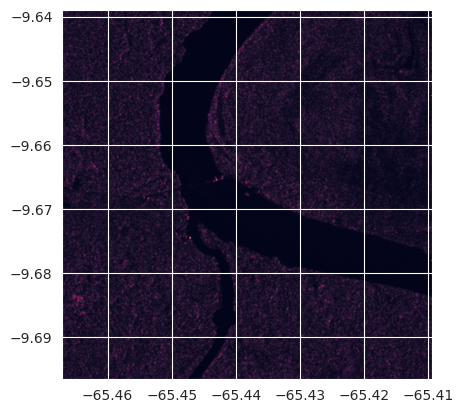

<Axes: >

In [ ]:
plot.show(r_dst)

-32768.0
3.1828501
0.18131553


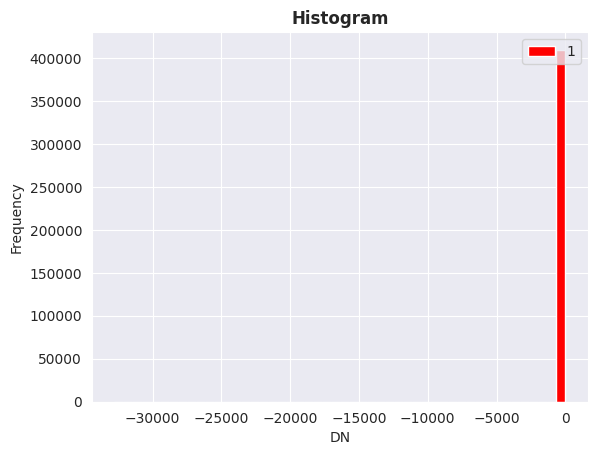

In [ ]:
print(min(r_dst.read().flatten()))
print(max(r_dst.read().flatten()))
print(np.percentile(r_dst.read(), 50))
plot.show_hist(r_dst.read(), bins=50)

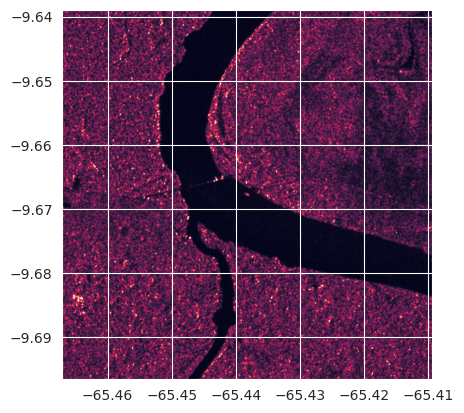

<Axes: >

In [ ]:
plot.show(r_dst,clim=[0,1])

In [ ]:
!cat output_file.vrt

<VRTDataset rasterXSize="28058" rasterYSize="19853">
  <SRS dataAxisToSRSAxisMapping="1,2">PROJCS["WGS 84 / UTM zone 20S",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-63],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",10000000],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32720"]]</SRS>
  <GeoTransform>  1.2457000000000000e+05,  1.0000000000000000e+01,  0.0000000000000000e+00,  9.0198700000000000e+06,  0.0000000000000000e+00, -1.0000000000000000e+01</GeoTransform>
  <VRTRasterBand dataType="Float32" band="1">
    <NoDataValue>-32768</NoDataValue>
    <ColorInterp>Gray</ColorInte

#4.Use functions to process locations/sites and multiple dates

In the previous section, we went through all the steps necesssary to process and download an asset with mosaicing, cropping and reprojection. This was useful to understand how STAC stores assets and how we can leverage GDAL with streaming and virtual files. In this section, we combine all the steps and turn the code into a function to process date by date and create a time series.


##4.1 Use a function to generate ouptut for one date using GDAL.WARP



We first show below a test on one date and then expand to the whole time range defined in the STAC query. Let's first get all the relevant products using a new function that:

- uses the constructed geodataframe from the STAC query
- filter for the band selected (e.g. vv, vh bands)
- filter for the platform (e.g. Sentinel 1A or 1B)

Let's use the new function we created to process a specific date. The parameters are as follow:

- date_val: date to process
- selected_products: data frame produced after filtering for the relevant products and containing the URL to access the asset as well as dates.
- download: if True, the raw STAC files are downloaded locally before processing otherwise, we use streaming.
- aoi_poly: reference AOI vector file or geodataframe
- output_epsg: if None, this will be infer from the the input AOI vector file.
- output_res: the output resolution for the new files
- output_dir: output directory path


Note that by default the processed images are placed in the following dir:
output_dir/collection/date/output_filename
where:

- out_dir = local path dir for the output
- collection = program missionwith platform name (e.g. Sentinel 1A)
- date
- outputfile name: by default the name is 'crop_proj'{collection}_assets.SCL

./sentinel-1-rtc/20210102/crop_proj_sentinel-1-rtc_assets.band_name.href_date.tif

e.g.:

./sentinel-1-rtc/20210102/crop_proj_sentinel-1-rtc_assets.SCL.href_20210102.tif

We are now ready to process files for each dates. Note again that multiple assets bands are processed since we provided the selected product data frame with multiple assets bands.
The time to process 186 dates was less than 20 minutes for AOI provided.

In [ ]:
list_centroids = list(coordinates_df.apply(lambda x: polygon_from_centroid(x_centroid=x['x'],y_centroid=x['y'],size=square_box_size),axis=1))
gdf_boat_poly_locations_gdf = pd.concat(list_centroids,axis=0).reset_index(drop=True)
gdf_boat_poly_locations_gdf['SAR_date'] = gdf_boat_locations['SAR_date']
gdf_boat_poly_locations_gdf

,geom,geometry,SAR_date
0,p1,"POLYGON ((-65.46705 -9.69652, -65.40945 -9.696...",2019-06-04
1,p1,"POLYGON ((-65.46672 -9.69669, -65.40912 -9.696...",2019-06-04
2,p1,"POLYGON ((-65.36464 -9.56731, -65.30704 -9.567...",2019-06-04
3,p1,"POLYGON ((-65.21699 -9.58266, -65.15939 -9.582...",2019-06-04
4,p1,"POLYGON ((-65.23528 -9.57918, -65.17768 -9.579...",2019-06-04
...,...,...,...
199,p1,"POLYGON ((-65.15806 -9.63022, -65.10046 -9.630...",2019-07-10
200,p1,"POLYGON ((-65.15238 -9.63325, -65.09478 -9.633...",2019-07-10
201,p1,"POLYGON ((-65.18197 -9.60336, -65.12437 -9.603...",2019-07-10
202,p1,"POLYGON ((-65.18511 -9.60394, -65.12751 -9.603...",2019-07-10


In [ ]:
list_xy = list(zip(coordinates_df.x, coordinates_df.y))
print(len(list_xy))
list_xy[:1]

204


[(-65.43825248958649, -9.667724763557548)]

In [ ]:
points_bbox_poly_gdf.explore()

In [ ]:

list_xy[:2]

[(-65.43825248958649, -9.667724763557548),
 (-65.43792154915076, -9.667890233775413)]

In [ ]:
#write a function to loop through a specific location

#https://gis.stackexchange.com/questions/299787/finding-pixel-location-in-raster-using-coordinates

#write a function to loop through a specific location
#This takes 45 minutes for 204 locations processing 2 bands and 7 dates or:
#204*7*2 = 2856 files

image_size = 640
res_val = 10 #in meters
URL = 'https://planetarycomputer.microsoft.com/api/stac/v1'
image_collections='sentinel-1-rtc'
#can be landsat or anything of interest
start_date
end_date
platform
band_selected = ['vv','vh']
#x_val =
#y_val =
output_epsg = None, #use the epsg from aoi_poly
output_res=0.00009
list_output_files_df = []
list_output_files = []

from datetime import datetime
start_time = datetime.now()

for i,tuple_xy in enumerate(list_xy[:2]):
  output_files = process_sites(i,
                      tuple_xy,
                      start_date,
                      end_date,
                      platform,
                      bands_selected,
                      image_size,
                      res_val,
                      URL,
                      image_collections,
                      output_epsg,
                      output_res)
  output_files_df = pd.DataFrame({'output_files':sum(output_files,[])})
  output_files_df['site'] = f'site_{i}'
  list_output_files.append(output_files)
  list_output_files_df.append(output_files_df)
end_time = datetime.now()
duration = end_time - start_time
print(f'Duration in second: {duration}')
#To compute time duration in minutes:
duration_minutes = (duration.seconds)/60
print(f'Duration in minutes: {duration_minutes}')

Duration in second: 0:00:40.849573
Duration in minutes: 0.6666666666666666


In [ ]:
raster_sites_df = pd.concat(list_output_files_df,axis=0).reset_index(drop=True)
raster_sites_df['path']=[os.path.dirname(os.path.normpath(path_val)) for path_val in raster_sites_df['output_files'].tolist()]
raster_sites_df['output_files']=[os.path.normpath(path_val) for path_val in raster_sites_df['output_files'].tolist()]
raster_sites_df['path'] =[os.path.join(out_dir,val_path) for val_path in raster_sites_df['site'].str.cat(raster_sites_df['path'], sep=os.sep).tolist()]
raster_sites_df['file'] = [os.path.basename(path_val) for path_val in raster_sites_df['output_files'].tolist()]
raster_sites_df['date'] = pd.to_datetime([file_val.split('_')[-1].split('.')[0] for file_val in raster_sites_df['file'].tolist()])
raster_sites_df.drop('output_files',axis=1,inplace=True)
raster_sites_df

,site,path,file,date
0,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-04
1,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-04
2,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-10
3,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-10
4,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-16
5,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-16
6,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-22
7,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-22
8,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-28
9,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-28


In [ ]:
gdf_boat_locations['site']= ['site_'+(str(i)) for i in np.arange(0,gdf_boat_locations.shape[0])]
raster_sites_df = raster_sites_df.merge(gdf_boat_locations,on='site',how='left')
raster_sites_df['boat_training'] = 0
raster_sites_df.loc[raster_sites_df['date']==raster_sites_df['SAR_date'],'boat_training']=1
raster_sites_df

,site,path,file,date,SAR_date,geometry,boat_training
0,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-04,2019-06-04,POINT (-65.43825 -9.66772),1
1,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-04,2019-06-04,POINT (-65.43825 -9.66772),1
2,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-10,2019-06-04,POINT (-65.43825 -9.66772),0
3,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-10,2019-06-04,POINT (-65.43825 -9.66772),0
4,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-16,2019-06-04,POINT (-65.43825 -9.66772),0
5,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-16,2019-06-04,POINT (-65.43825 -9.66772),0
6,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-22,2019-06-04,POINT (-65.43825 -9.66772),0
7,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-22,2019-06-04,POINT (-65.43825 -9.66772),0
8,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-28,2019-06-04,POINT (-65.43825 -9.66772),0
9,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-28,2019-06-04,POINT (-65.43825 -9.66772),0


In [ ]:
raster_sites_df['boat_training'].value_counts()

,count
boat_training,
0,24
1,4


In [ ]:
raster_sites_df['site'].value_counts()

,count
site,
site_0,14
site_1,14


In [ ]:
raster_sites_df.to_csv(os.path.join(out_dir,f'raster_sites_df_{out_suffix}.csv'),index=False)

#5.Rioxarray time series raster plot

We use rioxarray package to visulize the data. We will not read everything in memory but we will use a dask array. We modify the code from Virginie Bonnefond (see link below) to construct our xarray leveraging the rioxarray package by  using the path to the relevant Sentinel 1 files.

The tree structure is as follow:

```

./site_0
├── sentinel-1-rtc
│   ├── 20190604
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif
│   ├── 20190610
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190610.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190610.tif

```

The following dimensions are relevant for the xarray object:

- x: longitude
- y: latitude
- band: vh and vv for Sentinel 1 SAR
- time: there are 7 time steps spanning June and July 2019


When construcnting the xarray object we use xr.concat to add files across bands and time. Note that files are read using rioxarray with chunk to avoid reading anything in memory.

Useful links:

- https://medium.com/@bonnefond.virginie/handling-multi-temporal-satellite-images-with-xarray-30d142d3391


In [ ]:
from datetime import datetime
import xarray as xr
#from glob import glob
import glob
import os
import rioxarray as rxr

In [ ]:
i=0
data_dir = os.path.join(out_dir,f'site_{i}',image_collections)
data_dir

'/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc'

In [ ]:
!tree ./site_0

./site_0
├── aoi_poly_proj.cpg
├── aoi_poly_proj.dbf
├── aoi_poly_proj.prj
├── aoi_poly_proj.shp
├── aoi_poly_proj.shx
├── sentinel-1-rtc
│   ├── 20190604
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif
│   ├── 20190610
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190610.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190610.tif
│   ├── 20190616
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190616.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190616.tif
│   ├── 20190622
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190622.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190622.tif
│   ├── 20190628
│   │   ├── site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190628.tif
│   │   └── site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190628.tif
│   ├── 20190704
│   │   ├── site_0_crop_proj_sentinel-1-

In [ ]:
print(data_dir)

/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc


In [ ]:
scenes = []
scene_directories = glob.glob(os.path.join(data_dir, '*/'))
time_var = xr.Variable('time', paths_to_datetimeindex(scene_directories))
for scene_dir in scene_directories:
    bands = []
    band_paths = glob.glob(os.path.join(scene_dir, '*tif'))
    for band_path in band_paths:
        #band_name = band_path.split('_')[2]
        band_name = band_path.split('_')[-2].split('.')[1] #modified by Benoit
        band = rxr.open_rasterio(band_path, chunks={'x':512, 'y':512}) # Specify chunk size
        #band = rxr.open_rasterio(band_path, cache=False) # Specify chunk size
        #band['band'] = [band_path.split('_')[2]]
        band['band'] = [band_name]
        bands.append(band)
    scene = xr.concat(bands, dim='band')
    scenes.append(scene)
time_series_scenes = xr.concat(scenes, dim=time_var)

/tmp/ipython-input-1171770247.py:17: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'band' ('band',) The recommendation is to set join explicitly for this case.
  time_series_scenes = xr.concat(scenes, dim=time_var)


In [ ]:
print(type(scene))
print(time_var)
scene_directories

<class 'xarray.core.dataarray.DataArray'>
<xarray.Variable (time: 7)> Size: 56B
array(['2019-06-04T00:00:00.000000000', '2019-06-10T00:00:00.000000000',
       '2019-06-16T00:00:00.000000000', '2019-06-22T00:00:00.000000000',
       '2019-06-28T00:00:00.000000000', '2019-07-04T00:00:00.000000000',
       '2019-07-10T00:00:00.000000000'], dtype='datetime64[ns]')


['/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190610/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190616/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190622/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190628/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190704/',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_

In [ ]:
time_series_scenes

<xarray.DataArray (time: 7, band: 2, y: 640, x: 640)> Size: 23MB
dask.array<concatenate, shape=(7, 2, 640, 640), dtype=float32, chunksize=(1, 1, 512, 512), chunktype=numpy.ndarray>
Coordinates:
  * x            (x) float64 5kB -65.47 -65.47 -65.47 ... -65.41 -65.41 -65.41
  * y            (y) float64 5kB -9.639 -9.639 -9.639 ... -9.696 -9.696 -9.696
  * band         (band) <U2 16B 'vh' 'vv'
    spatial_ref  int64 8B 0
  * time         (time) datetime64[ns] 56B 2019-06-04 2019-06-10 ... 2019-07-10
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     0.0
    scale_factor:   1.0
    add_offset:     0.0

In [ ]:
time_series_scenes.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [ ]:
time_series_scenes.rio.bounds()

(-65.4670524895865, -9.696524763557543, -65.4094524895865, -9.638924763557542)

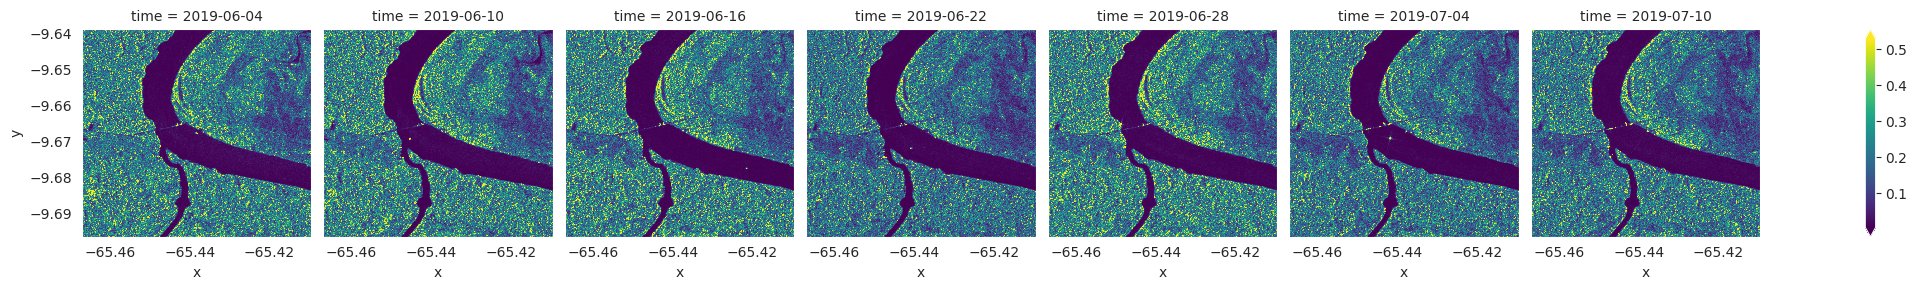

In [ ]:
all_bands = ['vv']
time_series_scenes.sel(band=all_bands).plot(col='time', robust=True) #if pass plot.imshow we need RGB

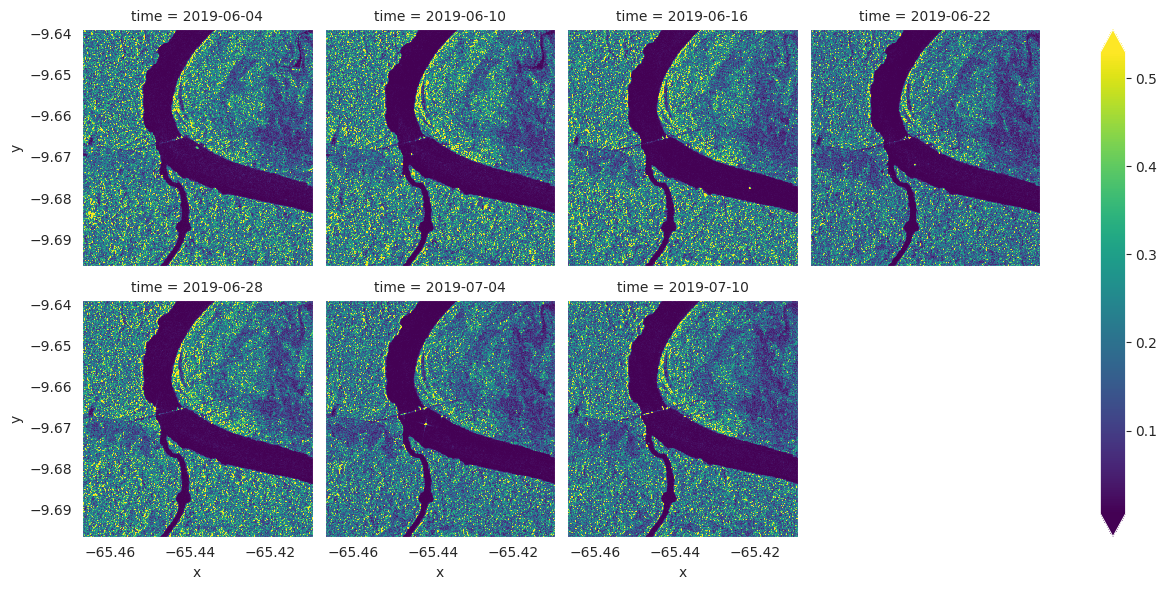

In [ ]:
all_bands = ['vv']
time_series_scenes.sel(band=all_bands).plot(col='time',
                                            robust=True,
                                            col_wrap=4) #if pass plot.imshow we need RGB

In [ ]:
raster_sites_df.loc[raster_sites_df['site']=='site_1']

,site,path,file,date,SAR_date,geometry,boat_training
14,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-04,2019-06-04,POINT (-65.43792 -9.66789),1
15,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-04,2019-06-04,POINT (-65.43792 -9.66789),1
16,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-10,2019-06-04,POINT (-65.43792 -9.66789),0
17,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-10,2019-06-04,POINT (-65.43792 -9.66789),0
18,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-16,2019-06-04,POINT (-65.43792 -9.66789),0
19,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-16,2019-06-04,POINT (-65.43792 -9.66789),0
20,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-22,2019-06-04,POINT (-65.43792 -9.66789),0
21,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-22,2019-06-04,POINT (-65.43792 -9.66789),0
22,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-28,2019-06-04,POINT (-65.43792 -9.66789),0
23,site_1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_1_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-28,2019-06-04,POINT (-65.43792 -9.66789),0


The first scene contains the boat near the river bank. Let's zoom in.

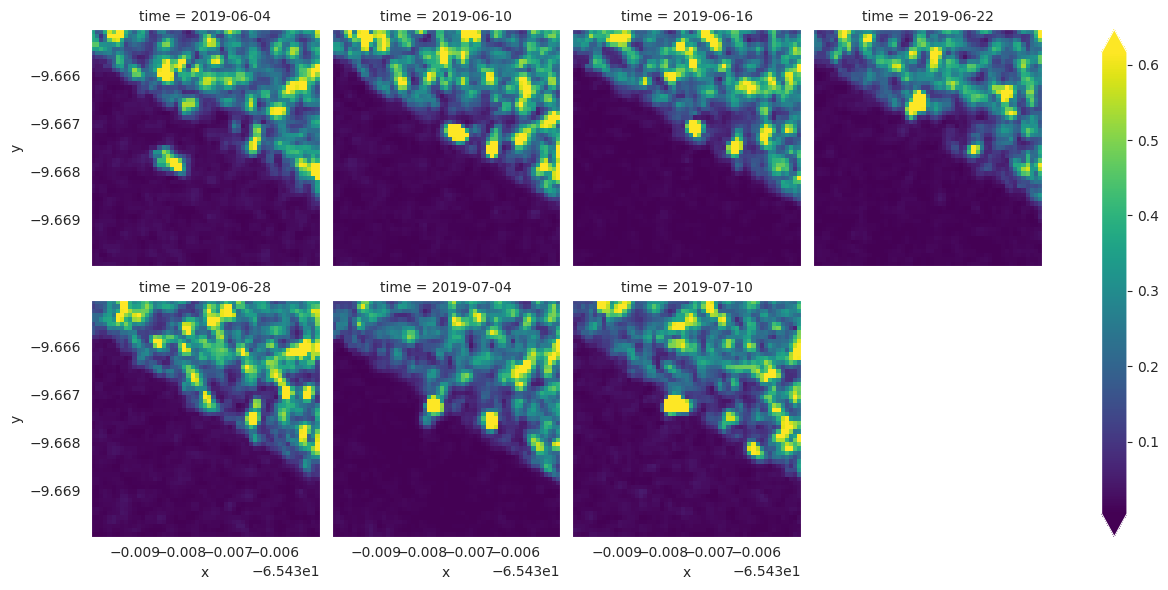

In [ ]:
sample = time_series_scenes.sel(x=slice(-65.440,-65.435),y=slice(-9.665,-9.670))
sample.sel(band=all_bands).plot(col='time',
                                robust=True,
                                col_wrap=4)

The boat appears to be a group of several pixels so we can start building bounding box for object detection. Next, we will look for a pre-trained model to re-use the weight in fine-tuning and generate boxes and training for boats and no boats classes.

- https://space.elspina.tech/how-to-annotate-bounding-boxes-with-the-geospatial-data-3dbc7d503f61

#6.Processing images for labeling and training inputs


We have created the image patches and now we need to process them


- Create multiband file with vv vh and vv/vh
- Stretch image band and rescale to 0-
- Convert to png


Links

Perhaps you should update your gdal. Using version 2.4.0 I can generate 16bit PNGs with this command:
$ gdal_translate -of PNG -ot UInt16 -scale 32.53501 767.4913 0 65535 goes16.abi-2019.0902.1510-C01_1km.tif k.png $ pngcheck k.png OK: k.png (2574x1591, 16-bit grayscale, non-interlaced, 35.0%).

https://gis.stackexchange.com/questions/246934/translating-geotiff-to-16-bit-png-with-gdal

Fix input channel issue:

https://medium.com/internet-of-technology/yolov9-1-channel-training-9f18eff2f4f8


In [ ]:
raster_sites_df = pd.read_csv(os.path.join(out_dir,f'raster_sites_df_{out_suffix}.csv'))
raster_sites_df

,site,path,file,date,SAR_date,geometry,boat_training
0,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-04,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),1
1,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-04,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),1
2,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-10,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
3,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-10,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
4,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-16,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
5,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-16,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
6,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-22,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
7,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-22,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
8,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vv.href...,2019-06-28,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0
9,site_0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,site_0_crop_proj_sentinel-1-rtc_assets.vh.href...,2019-06-28,2019-06-04,POINT (-65.43825248958649 -9.667724763557548),0


In [ ]:
bands_selected_color_composite = bands_selected #note that in this case the RGB band selected are the same as the bands extracted!!

In [ ]:
list_df_files_raster = []
bands_pattern_val_list = bands_selected_color_composite
for band_pattern_val in bands_pattern_val_list:
  in_dir_files =  os.path.join(out_dir,'*',image_collections,'*')
  file_pattern = f'*crop_proj_sentinel*{band_pattern_val}*.tif'
  path_raster = os.path.join(in_dir_files,file_pattern) #raw raster
  files_raster_sat = glob.glob(path_raster,recursive=True)
  df_files_raster_val = pd.DataFrame({'files':files_raster_sat})
  list_df_files_raster.append(df_files_raster_val)

df_files_raster_RGB = pd.concat(list_df_files_raster,axis=1)
df_files_raster_RGB.columns=bands_pattern_val_list

df_files_raster_RGB['date'] = (df_files_raster_RGB[bands_pattern_val_list[0]].str.split("_").str[-1]).str.replace(".tif","")
df_files_raster_RGB['date'] = (pd.to_datetime(df_files_raster_RGB['date']))
df_files_raster_RGB = df_files_raster_RGB.sort_values(by='date')
df_files_raster_RGB = df_files_raster_RGB.reset_index(drop=True)

#adding site
df_files_raster_RGB['site']=['_'.join((os.path.basename(x)).split('_')[0:2]) for x in df_files_raster_RGB['vv'].tolist()]
df_files_raster_RGB

,vv,vh,date,site
0,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-04,site_0
1,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-04,site_1
2,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-10,site_0
3,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-10,site_1
4,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-16,site_0
5,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-16,site_1
6,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-22,site_0
7,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-22,site_1
8,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-28,site_0
9,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,/content/gdrive/MyDrive/Colab Notebooks/boat-d...,2019-06-28,site_1


In [ ]:
date_selected = '2019-06-04'
site_selected = 'site_0'
raster_file_list_m = df_files_raster_RGB.loc[(df_files_raster_RGB['date']==date_selected) & (df_files_raster_RGB['site']==site_selected)
                                             ,bands_pattern_val_list].values.flatten().tolist()
raster_file_list_m

['/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif',
 '/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif']

In [ ]:
os.chdir(out_dir)
output_filename = f'{site_selected}_ratio_vvvh_{date_selected}.tif'
date_val_formatted = date_selected.replace('-',"")
os.chdir(f'./{site_selected}/{image_collections}/{date_val_formatted}')

in_filename_vv = os.path.basename(raster_file_list_m[0])
in_filename_vh = os.path.basename(raster_file_list_m[1])
#output_filename_open,
#output_filename_partial
list_args =['gdal_calc.py',
            f'-A {in_filename_vv}',
            f'-B {in_filename_vh}',
            f'--calc="A/B"',
            '--hideNoData',
            '--overwrite',
            '--outfile',
            f'{output_filename}']

cmd_str = ' '.join([str(elem) for elem in list_args])
print(cmd_str)
import subprocess
env = os.environ.copy() #this is necessary in google colab
output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)
output_filename = os.path.join(out_dir,site_selected,image_collections,date_val_formatted,output_filename)
print(output_filename)
ds_vv_vh_ratio = rasterio.open(output_filename)
os.chdir(out_dir)
freq_array(ds_vv_vh_ratio)


gdal_calc.py -A site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif -B site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif --calc="A/B" --hideNoData --overwrite --outfile site_0_ratio_vvvh_2019-06-04.tif
/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_ratio_vvvh_2019-06-04.tif


,value,count
0,0.141257,1.0
1,0.166655,1.0
2,0.168042,1.0
3,0.187973,1.0
4,0.190772,1.0
...,...,...
400118,55.207558,1.0
400119,64.951523,1.0
400120,65.515434,1.0
400121,72.311066,1.0


                                                                                                                                                                                                             0
0  /content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif
1  /content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif
2                             /content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/site_0_ratio_vvvh_2019-06-04.tif


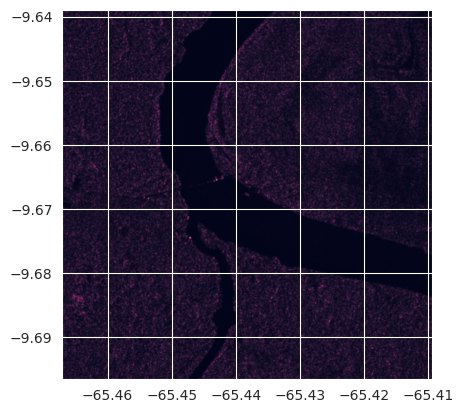

{'driver': 'VRT',
 'dtype': 'float32',
 'nodata': -32768.0,
 'width': 640,
 'height': 640,
 'count': 3,
 'crs': CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]'),
 'transform': Affine(9e-05, 0.0, -65.4670524895865,
        0.0, -9e-05, -9.638924763557542)}

In [ ]:
raster_list_RGB = raster_file_list_m + [output_filename]
print(pd.DataFrame(raster_list_RGB).to_string())
ds = gdal.BuildVRT( f'RGB_{site_selected}_{date_selected}.vrt',
                   raster_list_RGB,
                    separate=True, #keep files in separate bands, useful for files covering the same area
                    VRTNodata=NA_value,
                    srcNodata=NA_value)
#print(ds.RasterCount)
ds=None
dst = rasterio.open(f'RGB_{site_selected}_{date_selected}.vrt') #vv,vh,vv_vh_ratio
plot.show(dst)
dst.meta

Overwhelmy blue bcause ratio band vv over vh has much larger values and different distribution than vv and vh. We need to individually stretch the values.

[0.0, 3.1828501224517822, 0.1954398948524825, 0.14007144266029975]
[0.0, 0.8022962212562561, 0.04904936472037839, 0.03323196536717664]
[0.14125709235668182, 72.31106567382812, 4.435843822401762, 3.0729138092474275]


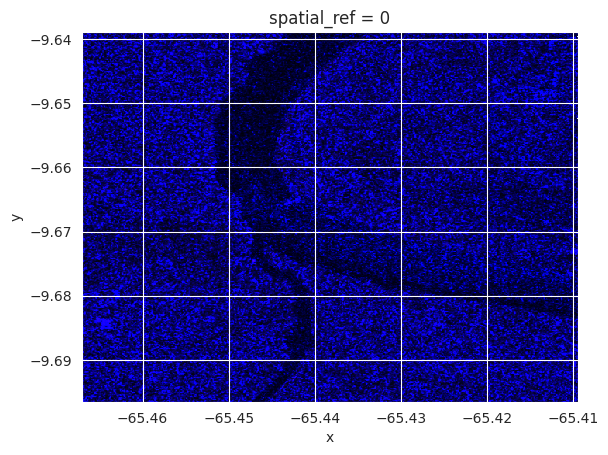

In [ ]:
#data.plot(col='band',robust=True,col_wrap=3)
rds = rxr.open_rasterio(f'RGB_{site_selected}_{date_selected}.vrt', masked=True,cache=False)
rds
rds.astype("float32").plot.imshow(rgb="band",robust=True)
in_filename = (f'RGB_{site_selected}_{date_selected}.vrt')
#dst_test.GetRasterBand(1).GetStatistics(0,1)
ds = gdal.Open(in_filename)
for i in range(1, ds.RasterCount + 1):
  #print(ds.GetRasterBand(i).GetStatistics(0,1))
  stats=ds.GetRasterBand(i).GetStatistics(0,1)
  print(stats)

Compute 2 or 98 percentile

In [ ]:
df_stats_RGB = calculate_image_stats(in_filename=in_filename)
df_stats_RGB

,perc_2,perc_98,band,min,max
0,0.006972,0.544708,0,0.000000,3.182850
1,0.003356,0.130641,1,0.000000,0.802296
2,0.959473,13.070463,2,0.141257,72.311066


gdal_translate -scale_1 0.0069723670370876786 0.5447079408168796 0 1 -scale_2 0.003355925870127976 0.1306411337852478 0 1 -scale_3 0.9594729495048523 13.070462818145751 0 1 -exponent 1 -ot Float32 RGB_site_0_2019-06-04.vrt RGB_streched_site_0_2019-06-04.tif


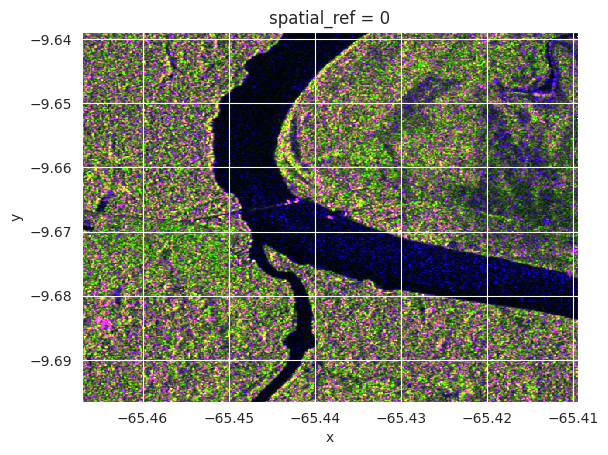

In [ ]:
out_filename,cmd_str=create_RGB(in_filename=f'RGB_{site_selected}_{date_selected}.vrt',
           out_filename=f'RGB_streched_{site_selected}_{date_selected}.tif',
           minmax=False,
           out_dtype='Float32')
print(cmd_str)
out_filename
rds2 = rxr.open_rasterio(out_filename, masked=True,cache=False)
rds2
rds2.plot.imshow(rgb="band",robust=False)

gdal_translate -scale_1 0.0069723670370876786 0.5447079408168796 0 255 -scale_2 0.003355925870127976 0.1306411337852478 0 255 -scale_3 0.9594729495048523 13.070462818145751 0 255 -exponent 1 -ot Byte RGB_site_0_2019-06-04.vrt RGB_streched_site_0_2019-06-04.tif


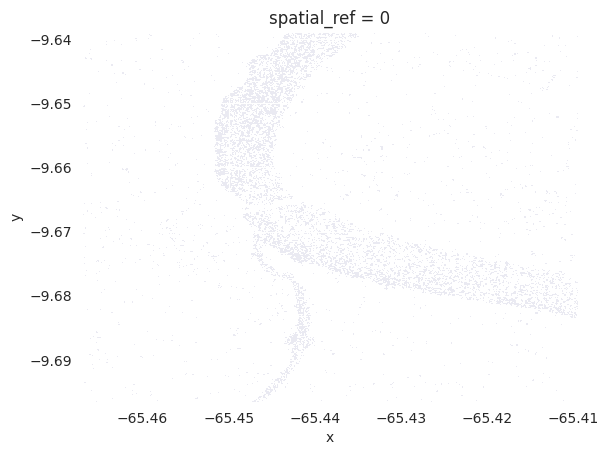

In [ ]:
out_filename,cmd_str=create_RGB(in_filename=f'RGB_{site_selected}_{date_selected}.vrt',
           out_filename=f'RGB_streched_{site_selected}_{date_selected}.tif',
           minmax=False,
           out_dtype='Byte')
print(cmd_str)
out_filename
rds2 = rxr.open_rasterio(out_filename, masked=True,cache=False)
rds2
rds2.plot.imshow(rgb="band",robust=False)


In [ ]:
'''
from osgeo import gdal

scale = '-scale min_val max_val'
options_list = [
    '-ot Byte',
    '-of JPEG',
    scale
]
options_string = " ".join(options_list)

gdal.Translate('test.jpg',
               'test.tif',
               options=options_string)
'''

'\nfrom osgeo import gdal\n\nscale = \'-scale min_val max_val\'\noptions_list = [\n    \'-ot Byte\',\n    \'-of JPEG\',\n    scale\n]\noptions_string = " ".join(options_list)\n\ngdal.Translate(\'test.jpg\',\n               \'test.tif\',\n               options=options_string)\n'

In [ ]:
#str(Path(out_filename).with_suffix(f'.{file_format}')) #replace suffix tiff with png
#file_format = 'PNG'
#file_format.lower()

NameError: name 'file_format' is not defined

In [ ]:
#gdal_translate -of PNG -co WORLDFILE=YES input_file.tif output_file.png

file_format = 'PNG'
in_filename_tif = out_filename
out_filename_format = str(Path(in_filename_tif).with_suffix(f'.{file_format.lower()}'))
list_args = ['gdal_translate',
             f'-ot Byte',
             f'-of {file_format}',
             f'-co WORLDFILE=YES',
             f'-scale',
             in_filename_tif,
             out_filename_format]

cmd_str = ' '.join([str(elem) for elem in list_args])
import subprocess
env = os.environ.copy() #this is necessary in google colab
output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)
print(cmd_str)

gdal_translate -ot Byte -of PNG -co WORLDFILE=YES -scale RGB_streched_site_0_2019-06-04.tif RGB_streched_site_0_2019-06-04.png


In [ ]:
!ls -ltr *.png

-rw------- 1 root root 1049049 Oct  3 16:38 RGB_streched_site_0_2019-06-04.png


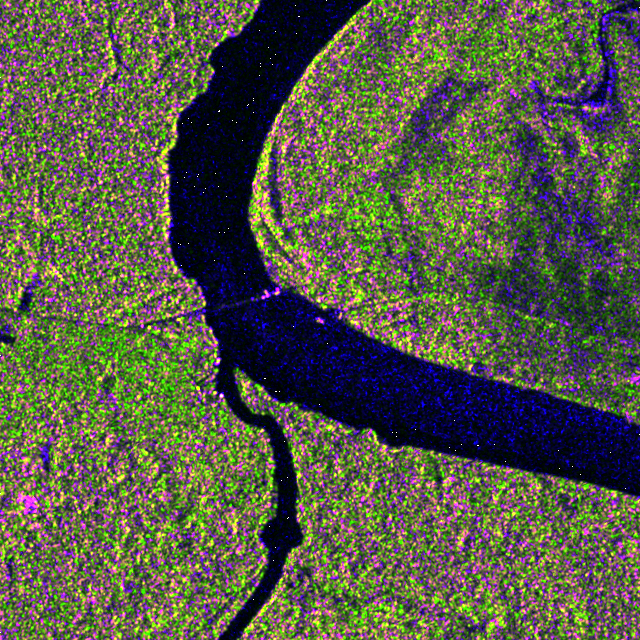

In [ ]:
from IPython.display import Image
#Image(filename='/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20250205/site_108/sentinel-1-rtc/20190604/RGB_streched_site_108_2019-06-04.png')
Image('RGB_streched_site_0_2019-06-04.png')

https://gdal.org/en/stable/drivers/raster/png.html
https://gdal.org/en/stable/drivers/raster/wld.html#raster-wld

pixel X size
rotation about the Y axis (usually 0.0)
rotation about the X axis (usually 0.0)
negative pixel Y size
X coordinate of upper left pixel center
Y coordinate of upper left pixel center

#now run this in a loop

In [ ]:
#i
date_selected = df_files_raster_RGB.loc[i,'date'].strftime('%Y-%m-%d')
date_selected
#(date_selected)
#date_selected.strftime('%Y-%m-%d')


'2019-06-10'

In [ ]:
np.arange(0,df_files_raster_RGB.shape[0])[466:]

array([], dtype=int64)

In [ ]:
#quick and dirty for now, we can improve this later by making it a function and running in parallel

list_output_files_SAR_RGB = [] #
list_output_files_SAR_RGB_format = [] #png file

for i in np.arange(0,df_files_raster_RGB.shape[0])[1335:]:

  #first get the relevant filenames
  #date_selected = df_files_raster_RGB.loc[i,'date']
  date_selected = df_files_raster_RGB.loc[i,'date'].strftime('%Y-%m-%d')
  site_selected = df_files_raster_RGB.loc[i,'site']
  #date_selected = '2019-06-04'
  #site_selected = 'site_0'
  raster_file_list_m = df_files_raster_RGB.loc[(df_files_raster_RGB['date']==date_selected) & (df_files_raster_RGB['site']==site_selected)
                                             ,bands_pattern_val_list].values.flatten().tolist()
  #raster_file_list_m


  #Second: create the ratio vv/vh
  os.chdir(out_dir)
  output_filename = f'{site_selected}_ratio_vvvh_{date_selected}.tif'
  date_val_formatted = date_selected.replace('-',"")
  os.chdir(f'./{site_selected}/{image_collections}/{date_val_formatted}')

  in_filename_vv = os.path.basename(raster_file_list_m[0])
  in_filename_vh = os.path.basename(raster_file_list_m[1])
  #output_filename_open,
  #output_filename_partial
  list_args =['gdal_calc.py',
              f'-A {in_filename_vv}',
              f'-B {in_filename_vh}',
              f'--calc="A/B"',
              '--hideNoData',
              '--overwrite',
              '--outfile',
              f'{output_filename}']

  cmd_str = ' '.join([str(elem) for elem in list_args])
  print(cmd_str)
  import subprocess
  env = os.environ.copy() #this is necessary in google colab
  output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)
  output_filename = os.path.join(out_dir,site_selected,image_collections,date_val_formatted,output_filename)
  print(output_filename)
  ds_vv_vh_ratio = rasterio.open(output_filename)
  os.chdir(out_dir)
  #freq_array(ds_vv_vh_ratio)

  ## Third create the VRT

  raster_list_RGB = raster_file_list_m + [output_filename]
  #print(pd.DataFrame(raster_list_RGB).to_string())
  vrt_file = f'RGB_{site_selected}_{date_selected}.vrt'
  ds = gdal.BuildVRT(os.path.join(out_dir,site_selected,image_collections,date_val_formatted,vrt_file),
                   raster_list_RGB,
                    separate=True, #keep files in separate bands, useful for files covering the same area
                    VRTNodata=NA_value,
                    srcNodata=NA_value)
  #ds = gdal.BuildVRT( f'RGB_{site_selected}_{date_selected}.vrt',
  #                 raster_list_RGB,
  #                  separate=True, #keep files in separate bands, useful for files covering the same area
  #                  VRTNodata=NA_value,
  #                  srcNodata=NA_value)

  #print(ds.RasterCount)
  ds=None
  #dst = rasterio.open(f'RGB_{site_selected}_{date_selected}.vrt') #vv,vh,vv_vh_ratio
  #plot.show(dst)
  #dst.meta

  in_filename = (f'RGB_{site_selected}_{date_selected}.vrt')

  # Fourth stretch the image
  output_filename = f'RGB_streched_{site_selected}_{date_selected}.tif'

  os.chdir(f'./{site_selected}/{image_collections}/{date_val_formatted}')

  out_filename,cmd_str=create_RGB(in_filename=vrt_file,
           #out_filename=f'RGB_streched_{site_selected}_{date_selected}.tif',
           out_filename=output_filename,
           minmax=False,
           out_dtype='Float32')

  #out_filename,cmd_str=create_RGB(in_filename=f'RGB_{site_selected}_{date_selected}.vrt',
  #         #out_filename=f'RGB_streched_{site_selected}_{date_selected}.tif',
  #         out_filename=output_filename,
  #         minmax=False,
  #         out_dtype='Float32')
  print(cmd_str)

  file_format = 'PNG'
  in_filename_tif = out_filename
  out_filename_format = str(Path(in_filename_tif).with_suffix(f'.{file_format.lower()}'))
  list_args = ['gdal_translate',
             f'-ot Byte',
             f'-of {file_format}',
             f'-co WORLDFILE=YES',
             f'-scale',
             in_filename_tif,
             out_filename_format]
  cmd_str = ' '.join([str(elem) for elem in list_args])
  import subprocess
  env = os.environ.copy() #this is necessary in google colab
  output_sub = subprocess.check_output(cmd_str, shell=True, env=env,text=True)
  print(cmd_str)
  os.chdir(out_dir)

  list_output_files_SAR_RGB.append(os.path.join(out_dir,site_selected,image_collections,date_val_formatted,out_filename))
  list_output_files_SAR_RGB_format.append(os.path.join(out_dir,site_selected,image_collections,date_val_formatted,out_filename_format))

  #out_filename
  #rds2 = rxr.open_rasterio(out_filename, masked=True,cache=False)
  #rds2
  #rds2.plot.imshow(rgb="band",robust=False)




In [ ]:
#problem at 51,516,517,915,916,1332,333
#problem at 465+51=516
#516+399=915+417=1332+93
len(list_output_files_SAR_RGB_format)

0

In [ ]:
os.path.join(out_dir,site_selected,image_collections,date_val_formatted,out_filename)
os.path.join(out_dir,site_selected,image_collections,date_val_formatted,out_filename_format)


'/content/gdrive/MyDrive/Colab Notebooks/boat-detection-remote-sensing-deep-learning/outputs/output_data_20251001/site_0/sentinel-1-rtc/20190604/RGB_streched_site_0_2019-06-04.png'

In [ ]:
!ls -ltr site_1/sentinel-1-rtc/20190604/

total 3204
-rw------- 1 root root 1640062 Oct  3 14:03 site_1_crop_proj_sentinel-1-rtc_assets.vv.href_20190604.tif
-rw------- 1 root root 1640062 Oct  3 14:04 site_1_crop_proj_sentinel-1-rtc_assets.vh.href_20190604.tif


In [ ]:
#!file 'RGB_streched_site_0_2019-06-04.png'
!file RGB_streched_site_108_2019-06-04.tif

RGB_streched_site_108_2019-06-04.tif: cannot open `RGB_streched_site_108_2019-06-04.tif' (No such file or directory)


#6.Conclusions

In this notebook, I explored the visual detection of dredge small rive boat using Sentinel 1, satellite imagery data. We showed how to download and process Sentinel 1 data for multiple dates (almost three years) using COGS and STAC framework.

The overall gaol was also to show how to leverage Sentinel 1 data once procesed. We used Sentinel1 data in a visual way to inspect the detection and movements of boats across 7 days and multiple location near El Borach on the border between Brazil and Bolivia.

We cropped the data to create image chips that can be used in a Deep Learning model training. The next step consists in creating object boxes around the boat locations.



#7.References


Obregón, M.A., Rodrigues, G., Costa, M.J., et al. (2019). Validation of ESA Sentinel-2 L2A aerosol optical thickness and columnar water vapour during 2017-2018. Remote Sensing, 11(14), 1649. https://doi.org/10.3390/rs11141649

Schläpfer, D., Borel, C.C., Keller, J., et al. (1998). Atmospheric precorrected differential absorption technique to retrieve columnar water vapor. Remote Sensing of Environment, 65(3), 353-366. https://doi.org/10.1016/S0034-4257(98)00044-3.

Gascon F., Bouzinac C., Thépaut O., et al. (2017). Copernicus Sentinel-2A calibration and products validation status. Remote Sensing, 9(6), 584. https://doi.org/10.3390/rs9060584


In [ ]:
############################# END OF SCRIPT ###################################